# 기말고사 문제 2 — Beijing PM2.5 회귀 분석

> **기계학습 라이브러리 활용** · 기말 Take-home Exam
> 배점: **25점** (Part B 6 + Part C 14 + Part D 5)  ·  데이터 전처리(Part A)는 제공 코드

---

## 📌 시험 안내 (필독)

### 데이터
- **출처**: UCI ML Repository — Beijing PM2.5 Data Set
- **URL**: `https://raw.githubusercontent.com/jbrownlee/Datasets/master/pollution.csv`
- **샘플**: 43,824개 (시간별, 5년치)
- **타겟**: `pm2.5` 컬럼 (회귀)
- **특성**: 결측치 있음, 범주형(`cbwd` 풍향) 포함

---

## ⚠️ 학번 입력 (필수)

다음 셀의 `STUDENT_ID` 변수에 본인 학번을 입력하세요.
**입력하지 않으면 0점 처리됩니다.**

In [1]:
STUDENT_ID = "3085"   # ← 본인 학번 마지막 4자리로 변경
SEED = int(STUDENT_ID)

assert STUDENT_ID != "0000", "학번을 입력하세요!"
print(f'학번(끝4자리): {STUDENT_ID}, SEED: {SEED}')

학번(끝4자리): 3085, SEED: 3085


## 환경 준비

필요한 라이브러리를 import하고 seed를 고정.

**요구사항**:
- numpy, pandas, matplotlib
- tensorflow, keras
- sklearn (train_test_split, StandardScaler)
- numpy와 tensorflow 모두 SEED로 고정


In [2]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ.setdefault('TF_ENABLE_ONEDNN_OPTS', '0')
os.environ.setdefault('MPLCONFIGDIR', '/tmp/mplconfig')
os.makedirs(os.environ['MPLCONFIGDIR'], exist_ok=True)

import warnings
warnings.filterwarnings('ignore', message=r'Glyph .* missing from font.*', category=UserWarning)
warnings.filterwarnings('ignore', message=r'.*Glyph .* missing from current font.*', category=UserWarning)
warnings.filterwarnings('ignore', message=r'Do not pass an `input_shape`/`input_dim` argument to a layer.*', category=UserWarning)

import contextlib
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

@contextlib.contextmanager
def suppress_native_stderr():
    stderr_fd = sys.stderr.fileno()
    saved_stderr_fd = os.dup(stderr_fd)
    try:
        with open(os.devnull, 'w') as devnull:
            os.dup2(devnull.fileno(), stderr_fd)
            yield
    finally:
        os.dup2(saved_stderr_fd, stderr_fd)
        os.close(saved_stderr_fd)

# TensorFlow/Keras 초기화 때 출력되는 CUDA/absl stderr 로그는 과제 출력과 무관하므로 숨긴다.
with suppress_native_stderr():
    import keras
    from keras import Sequential
    from keras.layers import Dense, Dropout, BatchNormalization, Activation
    from keras.regularizers import l2
    from keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report

# 재현성: 학번 기반 SEED로 고정 (numpy + 현재 keras 백엔드 동시 고정)
np.random.seed(SEED)
with suppress_native_stderr():
    keras.utils.set_random_seed(SEED)
    keras_backend_name = keras.backend.backend()

print('Keras  :', keras.__version__, '| backend:', keras_backend_name)
print('pandas :', pd.__version__)


I0000 00:00:1781877872.429519  424734 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Keras  : 3.14.1 | backend: tensorflow
pandas : 3.0.2


I0000 00:00:1781877873.688823  424734 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


---
데이터 전처리 (제공 코드 · 채점 제외)

## A1. 데이터 로드 및 결측치 처리 

1. URL에서 데이터를 로드
2. 전체 결측치 개수를 출력
3. 어느 컬럼에 결측치가 있는지 출력

**출력**:
- 원본 데이터 shape
- 처리 전 결측치 개수
- 처리 후 결측치 개수

In [3]:
# 데이터 로드
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pollution.csv'
df = pd.read_csv(url)

print('=== 원본 데이터 ===')
print(f'Shape: {df.shape}')
print(f'결측치 총 개수: {df.isnull().sum().sum()}')
print(f'결측치 컬럼별:\n{df.isnull().sum()[df.isnull().sum() > 0]}')

print(df.head(10))

print(df.tail(10))
print(df.info())
print(df.describe())

# 컬럼 목록
print(f'Columns: {df.columns}') 
#Index(['No', 'year', 'month', 'day', 'hour', 'pm2.5', 'DEWP', 'TEMP', 'PRES','cbwd', 'Iws', 'Is', 'Ir'],
print(df.columns.tolist())
#['No', 'year', 'month', 'day', 'hour', 'pm2.5', 'DEWP', 'TEMP', 'PRES', 'cbwd', 'Iws', 'Is', 'Ir']
print(df.dtypes)
display(df.head())

print(' === 1단계 : 컬럼 역할 1차 정리 ===')
# 데이터프레임을 바탕으로, 데이터샘플의 컬럼과 의미를 이해함이 목적.
# 트랜스포즈(전치)하지 않고, 모든 텍스트 전부 들어가게 출력
from IPython.display import display, HTML

col_info = pd.DataFrame({
    'column': ['No', 'year', 'month', 'day', 'hour', 'pm2.5', 'DEWP', 'TEMP', 'PRES', 'cbwd', 'Iws', 'Is', 'Ir'],
    '1_초기분류': [
        'id',
        'time',
        'time',
        'time',
        'time',
        'target',
        'numeric_feature',
        'numeric_feature',
        'numeric_feature',
        'categorical_feature',
        'numeric_feature',
        'numeric_feature',
        'numeric_feature'
    ],
    '2_라벨': [
        '행 번호. 관측 순서 또는 ID, = ~feature',
        '관측 연도',
        '관측 월',
        '관측 일',
        '관측 시각',
        'PM2.5 초미세먼지 농도. µg/m³단위',
        'Dew Point, ℃, 이슬점 //습도 상태를 나타내는 기상 feature',
        'Temperature, ℃, 기온 //계절, 난방, 대기 안정성과 연결되는 feature',
        'Pressure, hPa, 기압고기압/저기 // 대기 정체와 관련된 feature',
        'Combined Wind Direction, 풍향, NW, NE, SE, 등 범주형, // 풍향+본데이터에선 오염물질질 유입/확산 방향 feature',
        'Cumulated Wind Speed, 누적 풍속. m/s // 풍향에 따른 확산 정도 feature, 누적 풍속',
        'Cumulated hours of Snow, IS, 시간, 누적 눈 시간 // 강수·계절(겨울) feature',
        'Cumulated hours of rain, IR, 누적 비 시간. // 누적강수량, 본 데이터에선 대기오염 개선 효과 feature'
    ],
    '3_도메인심화' : [
        'N/A',
        'N/A',
        'N/A',
        'N/A',
        'N/A',
        'Particulate Matter 2.5 / (m2.5 = 100)=공기 1m³ 안에 PM2.5 질량 100µg. 대기오염의 결과값.',
        'DEWP가 그 기온(TEMP = 기온)에 비해 가까우면 공기가 습한 편으로 해석. ',
        '계절성과 생활·산업 활동의 proxy 역할 / 겨울에는 난방, 대기 정체 OR 여름에는 대기혼합 등',
        '“공기가 잘 섞이는 상태인가, 정체되는 상태인가”, 고기압성? 저기압? =강한 바람·강수 상황? ',
        'NW는 북서풍, NE는 북동풍, SE는 남동풍. cv는 보통 calm/variable',
        '“공기가 얼마나 많이 이동했는가”=환기·확산 능력',
        'wet deposition, 즉 세정 효과 + 계절요인',
        '상동'
    ]
})

# 각 셀의 줄 바꿈이 발생하도록 style 확장 (css =pre-line 적용)
styles = [
    dict(selector="td", props=[("white-space", "pre-line"), ("max-width", "320px")]),
    dict(selector="th", props=[("white-space", "pre-line")])
]
display(HTML(col_info.style.set_table_styles(styles).set_properties(**{'height': 'auto'}).to_html()))

=== 원본 데이터 ===
Shape: (43824, 13)
결측치 총 개수: 2067
결측치 컬럼별:
pm2.5    2067
dtype: int64
   No  year  month  day  hour  pm2.5  DEWP  TEMP    PRES cbwd    Iws  Is  Ir
0   1  2010      1    1     0    NaN   -21 -11.0  1021.0   NW   1.79   0   0
1   2  2010      1    1     1    NaN   -21 -12.0  1020.0   NW   4.92   0   0
2   3  2010      1    1     2    NaN   -21 -11.0  1019.0   NW   6.71   0   0
3   4  2010      1    1     3    NaN   -21 -14.0  1019.0   NW   9.84   0   0
4   5  2010      1    1     4    NaN   -20 -12.0  1018.0   NW  12.97   0   0
5   6  2010      1    1     5    NaN   -19 -10.0  1017.0   NW  16.10   0   0
6   7  2010      1    1     6    NaN   -19  -9.0  1017.0   NW  19.23   0   0
7   8  2010      1    1     7    NaN   -19  -9.0  1017.0   NW  21.02   0   0
8   9  2010      1    1     8    NaN   -19  -9.0  1017.0   NW  24.15   0   0
9  10  2010      1    1     9    NaN   -20  -8.0  1017.0   NW  27.28   0   0
          No  year  month  day  hour  pm2.5  DEWP  TEMP    PRES cbwd

,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir
0,1,2010,1,1,0,NaN,-21,-11.0,1021.0,NW,1.79,0,0
1,2,2010,1,1,1,NaN,-21,-12.0,1020.0,NW,4.92,0,0
2,3,2010,1,1,2,NaN,-21,-11.0,1019.0,NW,6.71,0,0
3,4,2010,1,1,3,NaN,-21,-14.0,1019.0,NW,9.84,0,0
4,5,2010,1,1,4,NaN,-20,-12.0,1018.0,NW,12.97,0,0


 === 1단계 : 컬럼 역할 1차 정리 ===


,column,1_초기분류,2_라벨,3_도메인심화
0,No,id,"행 번호. 관측 순서 또는 ID, = ~feature",N/A
1,year,time,관측 연도,N/A
2,month,time,관측 월,N/A
3,day,time,관측 일,N/A
4,hour,time,관측 시각,N/A
5,pm2.5,target,PM2.5 초미세먼지 농도. µg/m³단위,Particulate Matter 2.5 / (m2.5 = 100)=공기 1m³ 안에 PM2.5 질량 100µg. 대기오염의 결과값.
6,DEWP,numeric_feature,"Dew Point, ℃, 이슬점 //습도 상태를 나타내는 기상 feature",DEWP가 그 기온(TEMP = 기온)에 비해 가까우면 공기가 습한 편으로 해석.
7,TEMP,numeric_feature,"Temperature, ℃, 기온 //계절, 난방, 대기 안정성과 연결되는 feature","계절성과 생활·산업 활동의 proxy 역할 / 겨울에는 난방, 대기 정체 OR 여름에는 대기혼합 등"
8,PRES,numeric_feature,"Pressure, hPa, 기압고기압/저기 // 대기 정체와 관련된 feature","“공기가 잘 섞이는 상태인가, 정체되는 상태인가”, 고기압성? 저기압? =강한 바람·강수 상황?"
9,cbwd,categorical_feature,"Combined Wind Direction, 풍향, NW, NE, SE, 등 범주형, // 풍향+본데이터에선 오염물질질 유입/확산 방향 feature","NW는 북서풍, NE는 북동풍, SE는 남동풍. cv는 보통 calm/variable"


**결측치 처리 ** 

In [4]:
# 결측치 처리: pm2.5의 결측치는 시간 연속성을 활용한 forward fill로 채움
# (시간 연속 데이터이므로 직전 시간 값으로 채우는 것이 합리적)
# 대안: dropna() — 2067개(약 4.7%)이므로 제거도 가능

df_clean = df.copy()
df_clean['pm2.5'] = df_clean['pm2.5'].ffill().bfill()   # 시간 연속성 활용 (pandas 3.x 호환)

print(f'결측치 처리 후: {df_clean.isnull().sum().sum()}')
print(f'Shape: {df_clean.shape}')

결측치 처리 후: 0
Shape: (43824, 13)


## A2. 범주형 변수 인코딩

`cbwd` (풍향) 컬럼을 인코딩



In [5]:
print('cbwd 고유값:', df_clean['cbwd'].unique())
print('cbwd 분포:')
print(df_clean['cbwd'].value_counts())

# One-Hot 인코딩
df_clean = pd.get_dummies(df_clean, columns=['cbwd'], dtype=int)
print('\nOne-Hot 인코딩 후 컬럼:')
print([c for c in df_clean.columns if 'cbwd' in c])

cbwd 고유값: <StringArray>
['NW', 'cv', 'NE', 'SE']
Length: 4, dtype: str
cbwd 분포:
cbwd
SE    15290
NW    14150
cv     9387
NE     4997
Name: count, dtype: int64

One-Hot 인코딩 후 컬럼:
['cbwd_NE', 'cbwd_NW', 'cbwd_SE', 'cbwd_cv']


## A3. 시간 변수 처리

데이터에 이미 `year/month/day/hour` 컬럼이 있음. 요일, 주말 여부, 계절 등을 Feature로 생성


In [6]:
# datetime 컬럼 생성
df_clean['datetime'] = pd.to_datetime(df_clean[['year', 'month', 'day', 'hour']])
df_clean['dayofweek']  = df_clean['datetime'].dt.dayofweek
df_clean['is_weekend'] = (df_clean['dayofweek'] >= 5).astype(int)

# 불필요한 컬럼 제거
df_final = df_clean.drop(columns=['No', 'datetime'])

display('최종 컬럼:', df_final.columns.tolist())
print('Shape:', df_final.shape)

'최종 컬럼:'

['year',
 'month',
 'day',
 'hour',
 'pm2.5',
 'DEWP',
 'TEMP',
 'PRES',
 'Iws',
 'Is',
 'Ir',
 'cbwd_NE',
 'cbwd_NW',
 'cbwd_SE',
 'cbwd_cv',
 'dayofweek',
 'is_weekend']

Shape: (43824, 17)


## A4. Train/Val/Test 3분할 + 정규화

- 60% / 20% / 20% 비율로 3분할
- **반드시 `random_state=SEED`** 사용 (본인 학번 기반)
- StandardScaler로 정규화 (train에 fit, val/test는 transform만)

**출력**:
- X_train, X_val, X_test의 shape



In [7]:
# X, y 분리
y = df_final['pm2.5'].values.astype(np.float32)
X = df_final.drop(columns=['pm2.5']).values.astype(np.float32)

print(f'X: {X.shape}, y: {y.shape}')
print(f'타겟 분포: min={y.min():.1f}, max={y.max():.1f}, mean={y.mean():.1f}')

# 3분할 (60/20/20)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=SEED)
# 0.25 of 0.8 = 0.2 → 최종 60/20/20

print(f'\nTrain: {X_train.shape} ({len(X_train)/len(X):.0%})')
print(f'Val  : {X_val.shape} ({len(X_val)/len(X):.0%})')
print(f'Test : {X_test.shape} ({len(X_test)/len(X):.0%})')

# 정규화 (train에 fit, val/test는 transform만)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print('\n정규화 완료')

X: (43824, 16), y: (43824,)
타겟 분포: min=0.0, max=994.0, mean=97.8

Train: (26294, 16) (60%)
Val  : (8765, 16) (20%)
Test : (8765, 16) (20%)

정규화 완료


---
'''
# (추가입니다_ B0 EDA 심화)

    ## 0-1. 현재까지 상황정리 : 
        target: pm2.5 = 연속형 target

        numeric feature: year, month, day, hour, DEWP, TEMP, PRES, Iws, Is, Ir, dayofweek

        binary / dummy feature: cbwd_NE, cbwd_NW, cbwd_SE, cbwd_cv, is_weekend

    /단, month, hour, dayofweek는 숫자로 되어 있지만 coninuos 가 아닌보다는 categorical에 가까운 변수임에 유의.

**1. fix_train**:
- train 데이터 기준 fix. test 데이터까지 보고 가설을 세우면 간접적인 leakage. #시간 순서 split

**2. Target 중심 가설 설계**: 기본 target은 pm2.5 
- Q1. 수치형 기상 변수는 PM2.5와 선형 상관이 있는가?
    - numeric_features = ['DEWP', 'TEMP', 'PRES', 'Iws', 'Is', 'Ir']
    - H0: feature와 pm2.5 사이의 Pearson 상관계수는 0이다. 즉, 선형 상관관계가 없다.
    - H1: feature와 pm2.5 사이의 Pearson 상관계수는 0이 아니다.
    즉, 선형 상관관계가 있다.
    - p-value < 0.05: 귀무가설 기각. 해당 feature와 pm2.5 사이에 통계적으로 유의한 상관관계가 있다고 판단.
    - p-value >= 0.05: 귀무가설 기각 실패. 상관관계가 있다고 보기 어렵다.
    - corr > 0:
    feature가 커질수록 pm2.5도 증가하는 경향.
    - corr < 0:
    feature가 커질수록 pm2.5는 감소하는 경향.
    - abs(corr)가 클수록 관계 강도가 큼.

- Q2. 월별 PM2.5 평균은 같은가? -> month는 범주형에 가까우므로, 따라서 Pearson + groupby/boxplot/ANOVA
    - time_features = ['year', 'month', 'day', 'hour', 'dayofweek', 'is_weekend']
    - H0: 모든 월의 평균 pm2.5는 같다.
    - H1: 적어도 하나의 월은 평균 pm2.5가 다르다.
    - p-value < 0.05이면 월별 PM2.5 평균이 모두 같다는 귀무가설을 기각한다.
    - 즉, PM2.5에는 계절성 또는 월별 패턴이 있다고 볼 수 있다.

- Q3. 풍향 dummy(one-hot)와 PM2.5의 상관성.
    - dummy_features = ['cbwd_NE', 'cbwd_NW', 'cbwd_SE', 'cbwd_cv']
    - 각각은 0/1 binary feature임으로 따라서 각 dummy에 대해 다음 H0와 H1을 검정할 수 있다.
    - H0: 해당 풍향 여부에 따라 pm2.5 평균은 다르지 않다.
    - H1: 해당 풍향 여부에 따라 pm2.5 평균은 다르다.
  

**3. feature끼리의 상관성 파악**: feature 간 중복성 확인목적

- numeric_features_for_corr = ['year', 'month', 'day', 'hour', 'DEWP', 'TEMP', 'PRES', 'Iws', 'Is', 'Ir', 'dayofweek']
    - H0: 두 numeric feature 사이의 Pearson 상관계수는 0이다.
    - H1: 두 numeric feature 사이의 Pearson 상관계수는 0이 아니다.
    - EX) H0: DEWP와 TEMP 사이의 선형 상관은 없다. H1: DEWP와 TEMP 사이의 선형 상관이 있다.


In [8]:
print(' === 2단계 : Train 데이터 기준 Target 중심 EDA 가설 설정 ===')

target = 'pm2.5'

numeric_features = ['DEWP', 'TEMP', 'PRES', 'Iws', 'Is', 'Ir']
time_features = ['year', 'month', 'day', 'hour', 'dayofweek', 'is_weekend']
wind_dummy_features = ['cbwd_NE', 'cbwd_NW', 'cbwd_SE', 'cbwd_cv']

print('target:', target)
print('numeric_features:', numeric_features)
print('time_features:', time_features)
print('wind_dummy_features:', wind_dummy_features)

 === 2단계 : Train 데이터 기준 Target 중심 EDA 가설 설정 ===
target: pm2.5
numeric_features: ['DEWP', 'TEMP', 'PRES', 'Iws', 'Is', 'Ir']
time_features: ['year', 'month', 'day', 'hour', 'dayofweek', 'is_weekend']
wind_dummy_features: ['cbwd_NE', 'cbwd_NW', 'cbwd_SE', 'cbwd_cv']


In [9]:
from scipy.stats import pearsonr, spearmanr
from scipy.stats import ttest_ind, f_oneway, chi2_contingency
from scipy.stats import kruskal, mannwhitneyu


target = 'pm2.5'
numeric_weather_features = ['DEWP', 'TEMP', 'PRES', 'Iws', 'Is', 'Ir']
time_numeric_features = ['year', 'month', 'day', 'hour', 'dayofweek']
binary_features = ['cbwd_NE', 'cbwd_NW', 'cbwd_SE', 'cbwd_cv', 'is_weekend']
all_numeric_for_corr = [
    'year', 'month', 'day', 'hour',
    'DEWP', 'TEMP', 'PRES', 'Iws', 'Is', 'Ir',
    'dayofweek'
]

wind_dummy_features = ['cbwd_NE', 'cbwd_NW', 'cbwd_SE', 'cbwd_cv']

print('target:', target)
print('numeric_weather_features:', numeric_weather_features)
print('time_numeric_features:', time_numeric_features)
print('binary_features:', binary_features)
print('all_numeric_for_corr:', all_numeric_for_corr)

print('\n결측치 총 개수:', df_clean.isnull().sum().sum())
print('shape:', df_clean.shape)
display(df_clean.head())
display(df_clean.tail())
# 'cbwd_NE', 'cbwd_NW', 'cbwd_SE', 'cbwd_cv'의 값 비율 확인
for col in wind_dummy_features:
    ratio = df_clean[col].mean()
    display(f"{col} 날씨비율 : {ratio:.4f} ({ratio*100:.2f}%)")

target: pm2.5
numeric_weather_features: ['DEWP', 'TEMP', 'PRES', 'Iws', 'Is', 'Ir']
time_numeric_features: ['year', 'month', 'day', 'hour', 'dayofweek']
binary_features: ['cbwd_NE', 'cbwd_NW', 'cbwd_SE', 'cbwd_cv', 'is_weekend']
all_numeric_for_corr: ['year', 'month', 'day', 'hour', 'DEWP', 'TEMP', 'PRES', 'Iws', 'Is', 'Ir', 'dayofweek']



결측치 총 개수: 0
shape: (43824, 19)


,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,Iws,Is,Ir,cbwd_NE,cbwd_NW,cbwd_SE,cbwd_cv,datetime,dayofweek,is_weekend
0,1,2010,1,1,0,129.0,-21,-11.0,1021.0,1.79,0,0,0,1,0,0,2010-01-01 00:00:00,4,0
1,2,2010,1,1,1,129.0,-21,-12.0,1020.0,4.92,0,0,0,1,0,0,2010-01-01 01:00:00,4,0
2,3,2010,1,1,2,129.0,-21,-11.0,1019.0,6.71,0,0,0,1,0,0,2010-01-01 02:00:00,4,0
3,4,2010,1,1,3,129.0,-21,-14.0,1019.0,9.84,0,0,0,1,0,0,2010-01-01 03:00:00,4,0
4,5,2010,1,1,4,129.0,-20,-12.0,1018.0,12.97,0,0,0,1,0,0,2010-01-01 04:00:00,4,0


,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,Iws,Is,Ir,cbwd_NE,cbwd_NW,cbwd_SE,cbwd_cv,datetime,dayofweek,is_weekend
43819,43820,2014,12,31,19,8.0,-23,-2.0,1034.0,231.97,0,0,0,1,0,0,2014-12-31 19:00:00,2,0
43820,43821,2014,12,31,20,10.0,-22,-3.0,1034.0,237.78,0,0,0,1,0,0,2014-12-31 20:00:00,2,0
43821,43822,2014,12,31,21,10.0,-22,-3.0,1034.0,242.70,0,0,0,1,0,0,2014-12-31 21:00:00,2,0
43822,43823,2014,12,31,22,8.0,-22,-4.0,1034.0,246.72,0,0,0,1,0,0,2014-12-31 22:00:00,2,0
43823,43824,2014,12,31,23,12.0,-21,-3.0,1034.0,249.85,0,0,0,1,0,0,2014-12-31 23:00:00,2,0


'cbwd_NE 날씨비율 : 0.1140 (11.40%)'

'cbwd_NW 날씨비율 : 0.3229 (32.29%)'

'cbwd_SE 날씨비율 : 0.3489 (34.89%)'

'cbwd_cv 날씨비율 : 0.2142 (21.42%)'

In [10]:
print(' === B0-1. Train/Test 시간순 Split ===')
df_eda = df_clean.copy()
#시간 순서 정렬 : 과거데이터(2010-2013)을 바탕으로 미래데이터(test. 2014를 예측한다)
df_eda = df_eda.sort_values(['year', 'month', 'day', 'hour']).reset_index(drop=True)

train_df = df_eda[df_eda['year'] <= 2013].copy()
test_df = df_eda[df_eda['year'] == 2014].copy()

# train_size = int(len(df_eda) * 0.8) ,split 8:2시 35063  2013     12   31    23 에서 분기되는 것을 확인- 즉 기존 train+val : test 를 비율로 나눈것과 연도별 2010~2013:2014 마진은 동일함. // 단 확실하게 하기 위해 세부 연도별 분할

print(f'df_eda shape: {df_eda.shape}')
print(f'train_df shape: {train_df.shape}')
print(f'test_df shape: {test_df.shape}')

print('\nTrain 기간:')
print(train_df[['year', 'month', 'day', 'hour']].head(1))
print(train_df[['year', 'month', 'day', 'hour']].tail(1))

print('\nTest 기간:')
print(test_df[['year', 'month', 'day', 'hour']].head(1))
print(test_df[['year', 'month', 'day', 'hour']].tail(1))

print(' === “과거 4년으로 학습해서 다음 1년을 예측한다” ===')

 === B0-1. Train/Test 시간순 Split ===
df_eda shape: (43824, 19)
train_df shape: (35064, 19)
test_df shape: (8760, 19)

Train 기간:
   year  month  day  hour
0  2010      1    1     0
       year  month  day  hour
35063  2013     12   31    23

Test 기간:
       year  month  day  hour
35064  2014      1    1     0
       year  month  day  hour
43823  2014     12   31    23
 === “과거 4년으로 학습해서 다음 1년을 예측한다” ===


== 2-1 단계 : Target(pm2.5) 분포 확인 ===
= RQ0. pm2.5는 정규분포에 가까운가, 아니면 고농도 outlier가 많은 분포인가? =


count    35064.000000
mean        97.782883
std         90.748846
min          0.000000
1%           6.000000
5%          10.000000
25%         29.000000
50%         72.000000
75%        137.000000
95%        279.000000
99%        417.000000
max        994.000000
Name: pm2.5, dtype: float64

skewness: 1.8345
kurtosis: 5.3810


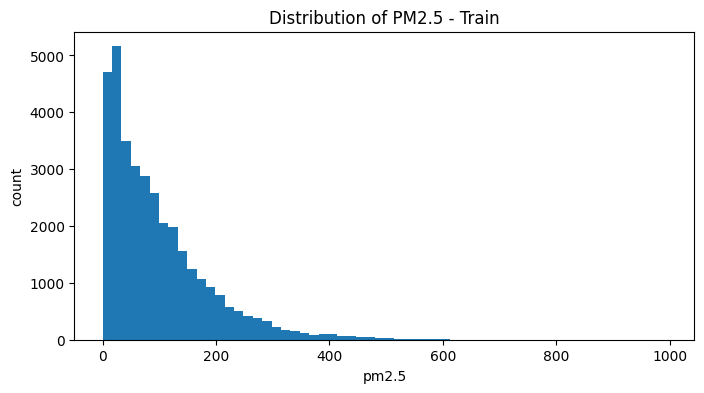

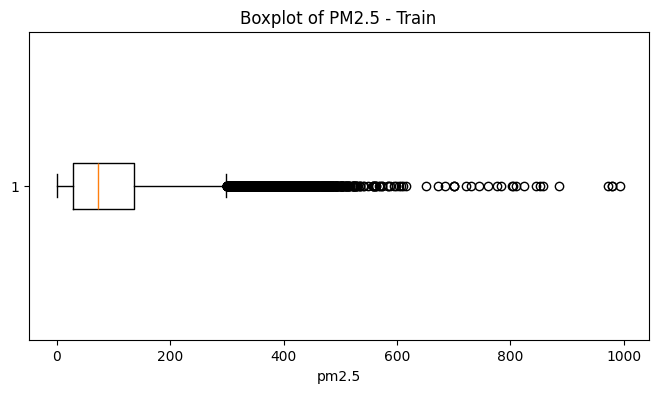

해석:
pm2.5는 평균이 중앙값보다 크고, skewness가 1.83으로 양의 왜도가 크다.
또한 75% 값은 137이지만 95%는 279, 99%는 417, 최대값은 994로 오른쪽 꼬리가 길다.
따라서 pm2.5는 정규분포라기보다 고농도 outlier가 많은 -즉, 특정 시간대나 계절·기상 조건에서 고농도 episode가 발생하는 데이터이다.
모델링에서는 MSE만 보면 고농도 오차에 크게 끌릴 수 있으므로 MAE, RMSE, log1p 변환, 고농도 여부 분류 등을 함께 고려할 필요가 있다.
=== 이때, outlier는 단순 오류라기보다 실제 대기오염 고농도 사건일 수 있다. 따라서 무조건 제거하면 안 된다. 이 데이터에서는 고농도 구간 자체가 중요한 예측 대상으로 판단될 수 있다.


In [11]:
print('== 2-1 단계 : Target(pm2.5) 분포 확인 ===')
print('= RQ0. pm2.5는 정규분포에 가까운가, 아니면 고농도 outlier가 많은 분포인가? =')

target_desc = train_df[target].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
)

display(target_desc)

print(f"skewness: {train_df[target].skew():.4f}")
print(f"kurtosis: {train_df[target].kurtosis():.4f}")

plt.figure(figsize=(8, 4))
plt.hist(train_df[target], bins=60)
plt.title('Distribution of PM2.5 - Train')
plt.xlabel('pm2.5')
plt.ylabel('count')
plt.show()

plt.figure(figsize=(8, 4))
plt.boxplot(train_df[target], vert=False)
plt.title('Boxplot of PM2.5 - Train')
plt.xlabel('pm2.5')
plt.show()

print('해석:')
print('pm2.5는 평균이 중앙값보다 크고, skewness가 1.83으로 양의 왜도가 크다.')
print('또한 75% 값은 137이지만 95%는 279, 99%는 417, 최대값은 994로 오른쪽 꼬리가 길다.')
print('따라서 pm2.5는 정규분포라기보다 고농도 outlier가 많은 -즉, 특정 시간대나 계절·기상 조건에서 고농도 episode가 발생하는 데이터이다.')
print('모델링에서는 MSE만 보면 고농도 오차에 크게 끌릴 수 있으므로 MAE, RMSE, log1p 변환, 고농도 여부 분류 등을 함께 고려할 필요가 있다.')
print('=== 이때, outlier는 단순 오류라기보다 실제 대기오염 고농도 사건일 수 있다. 따라서 무조건 제거하면 안 된다. 이 데이터에서는 고농도 구간 자체가 중요한 예측 대상으로 판단될 수 있다.')


=== 연속형 기상 feature ↔ 연속형 target ===


,feature,variable_type,test,pearson_direction,pearson_decision_0.05,pearson_corr,pearson_p_value,spearman_corr,spearman_p_value,abs_pearson,abs_spearman,H0,H1
3,Iws,continuous-continuous,Pearson / Spearman,negative,reject H0,-0.249642,0.000000e+00,-0.358043,0.000000e+00,0.249642,0.358043,Iws과 target 사이의 관계는 없다.,Iws과 target 사이의 관계는 있다.
0,DEWP,continuous-continuous,Pearson / Spearman,positive,reject H0,0.201941,2.142763e-319,0.331976,0.000000e+00,0.201941,0.331976,DEWP과 target 사이의 관계는 없다.,DEWP과 target 사이의 관계는 있다.
2,PRES,continuous-continuous,Pearson / Spearman,negative,reject H0,-0.092107,6.270519e-67,-0.189042,1.933085e-279,0.092107,0.189042,PRES과 target 사이의 관계는 없다.,PRES과 target 사이의 관계는 있다.
1,TEMP,continuous-continuous,Pearson / Spearman,negative,reject H0,-0.044800,4.743388e-17,0.064146,2.675477e-33,0.044800,0.064146,TEMP과 target 사이의 관계는 없다.,TEMP과 target 사이의 관계는 있다.
4,Is,continuous-continuous,Pearson / Spearman,positive,reject H0,0.023158,1.444966e-05,0.046936,1.449028e-18,0.023158,0.046936,Is과 target 사이의 관계는 없다.,Is과 target 사이의 관계는 있다.
5,Ir,continuous-continuous,Pearson / Spearman,negative,reject H0,-0.048251,1.563929e-19,0.006044,2.577713e-01,0.048251,0.006044,Ir과 target 사이의 관계는 없다.,Ir과 target 사이의 관계는 있다.


 === 시각화 1: 상관계수 bar plot. ===


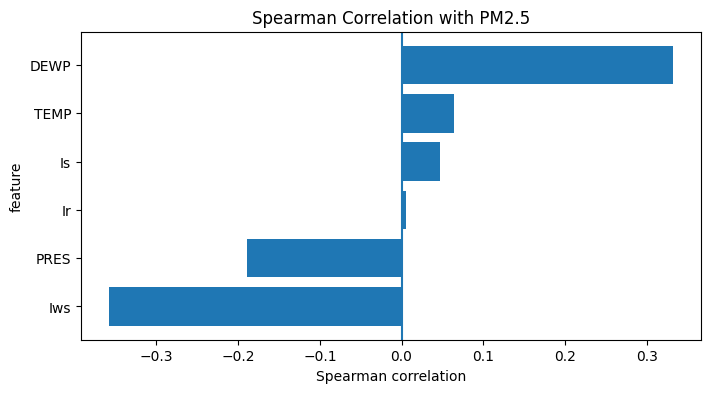

 === 2: 연속형 feature별 scatter plot ===


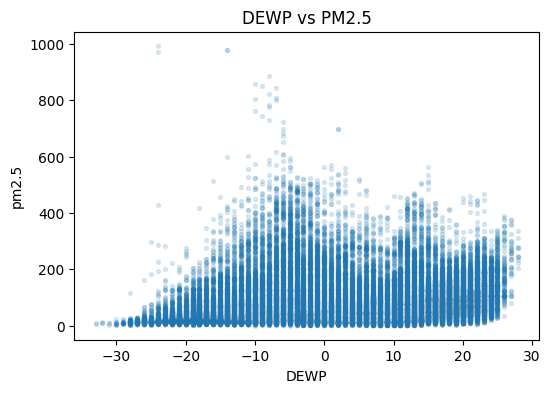

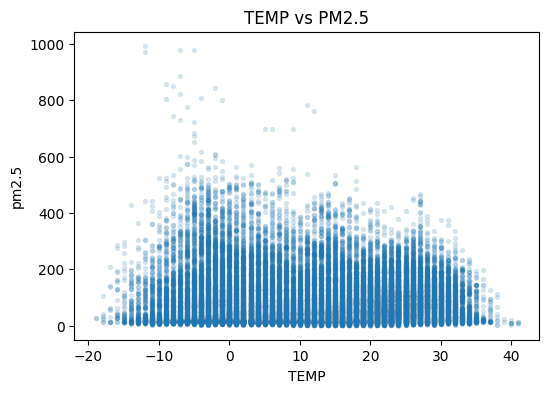

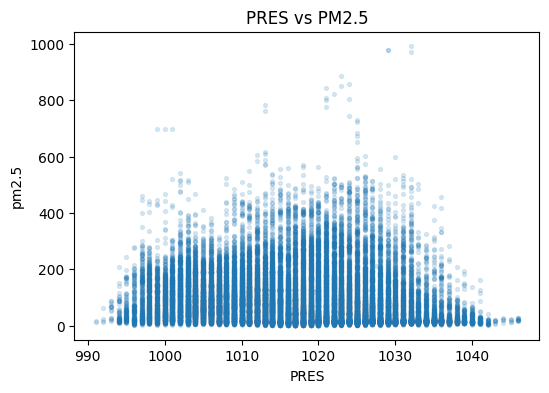

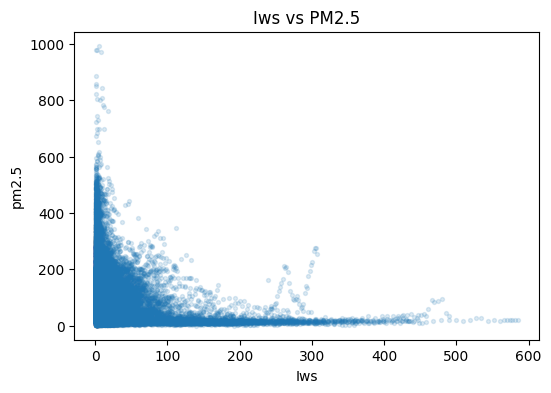

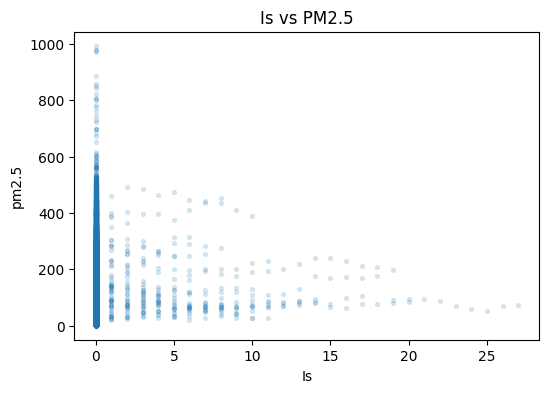

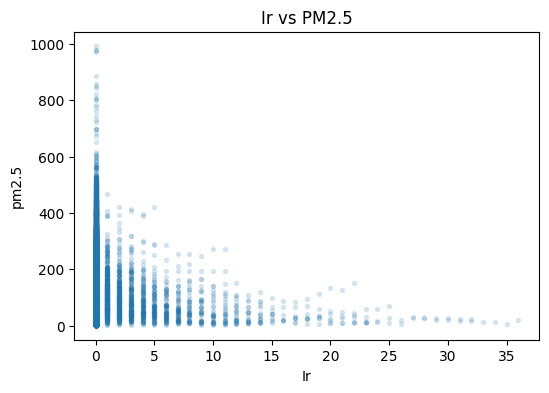

해석:
Iws는 pm2.5와 가장 강한 음의 상관을 보인다. 누적 풍속이 커질수록 PM2.5가 낮아지는 경향이 있다.
DEWP는 pm2.5와 비교적 뚜렷한 양의 상관을 보인다. 이슬점이 높을수록 PM2.5가 높아지는 경향이 있다.
PRES는 약한 음의 상관을 보인다.
TEMP는 Pearson과 Spearman의 방향이 달라 단순 선형 관계로 해석하기 어렵다.
Is와 Ir는 통계적으로 유의하거나 일부 유의하더라도 상관 강도가 매우 약하므로 주요 feature로 보기는 어렵다.
대규모 데이터에서는 p-value보다 correlation의 절대값과 시각적 패턴을 함께 해석해야 한다.


In [12]:
print('=== 연속형 기상 feature ↔ 연속형 target ===')
corr_rows = []

for col in numeric_weather_features:
    pearson_corr, pearson_p = pearsonr(train_df[col], train_df[target])
    spearman_corr, spearman_p = spearmanr(train_df[col], train_df[target])

    corr_rows.append({
        'feature': col,
        'variable_type': 'continuous-continuous',
        'test': 'Pearson / Spearman',
        'pearson_direction': 'positive' if pearson_corr > 0 else 'negative',
        'pearson_decision_0.05': 'reject H0' if pearson_p < 0.05 else 'fail to reject H0',
        'pearson_corr': pearson_corr,
        'pearson_p_value': pearson_p,
        'spearman_corr': spearman_corr,
        'spearman_p_value': spearman_p,
        'abs_pearson': abs(pearson_corr),
        'abs_spearman': abs(spearman_corr),
        'pearson_direction': 'positive' if pearson_corr > 0 else 'negative',
        'pearson_decision_0.05': 'reject H0' if pearson_p < 0.05 else 'fail to reject H0',
        'H0': f'{col}과 target 사이의 관계는 없다.',
        'H1': f'{col}과 target 사이의 관계는 있다.'
    })

corr_result = pd.DataFrame(corr_rows)
corr_result = corr_result.sort_values('abs_spearman', ascending=False)

display(corr_result)

print(' === 시각화 1: 상관계수 bar plot. ===')
plot_df = corr_result.sort_values('spearman_corr')

plt.figure(figsize=(8, 4))
plt.barh(plot_df['feature'], plot_df['spearman_corr'])
plt.axvline(0)
plt.title('Spearman Correlation with PM2.5')
plt.xlabel('Spearman correlation')
plt.ylabel('feature')
plt.show()

print(' === 2: 연속형 feature별 scatter plot ===')
for col in numeric_weather_features:
    plt.figure(figsize=(6, 4))
    plt.scatter(train_df[col], train_df[target], alpha=0.15, s=8)
    plt.title(f'{col} vs PM2.5')
    plt.xlabel(col)
    plt.ylabel('pm2.5')
    plt.show()


print('해석:')
print('Iws는 pm2.5와 가장 강한 음의 상관을 보인다. 누적 풍속이 커질수록 PM2.5가 낮아지는 경향이 있다.')
print('DEWP는 pm2.5와 비교적 뚜렷한 양의 상관을 보인다. 이슬점이 높을수록 PM2.5가 높아지는 경향이 있다.')
print('PRES는 약한 음의 상관을 보인다.')
print('TEMP는 Pearson과 Spearman의 방향이 달라 단순 선형 관계로 해석하기 어렵다.')
print('Is와 Ir는 통계적으로 유의하거나 일부 유의하더라도 상관 강도가 매우 약하므로 주요 feature로 보기는 어렵다.')
print('대규모 데이터에서는 p-value보다 correlation의 절대값과 시각적 패턴을 함께 해석해야 한다.')

| feature | Pearson | Spearman | 해석                                                |
| ------- | ------: | -------: | ------------------------------------------------- |
| `Iws`   |  -0.250 |   -0.358 | 가장 강한 음의 관계. 누적 풍속이 클수록 PM2.5가 낮아지는 경향            |
| `DEWP`  |   0.202 |    0.332 | 이슬점이 높을수록 PM2.5가 높아지는 경향                          |
| `PRES`  |  -0.092 |   -0.189 | 약한 음의 관계                                          |
| `TEMP`  |  -0.045 |    0.064 | 매우 약함. Pearson/Spearman 부호가 달라 단순 선형관계로 보기 어렵다    |
| `Is`    |   0.023 |    0.047 | 통계적으로는 유의하나 실질적 관계는 매우 약함                         |
| `Ir`    |  -0.048 |    0.006 | Spearman p-value가 0.2577로 유의하지 않음. 실질적으로 거의 관계 없음 |


 === scatter plot 개선 - 원본 target vs log1p target ===
원본 pm2.5 scatter는 고농도 outlier 때문에 낮은 구간의 구조가 잘 보이지 않을 수 있다.


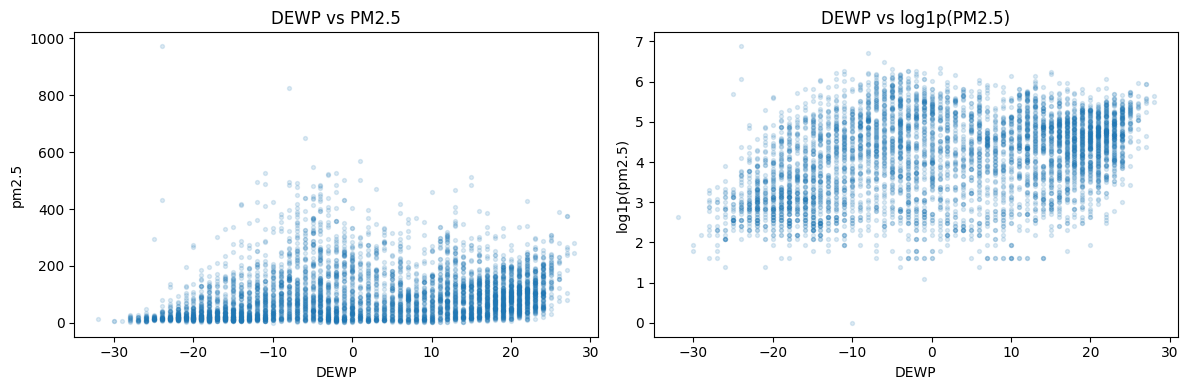

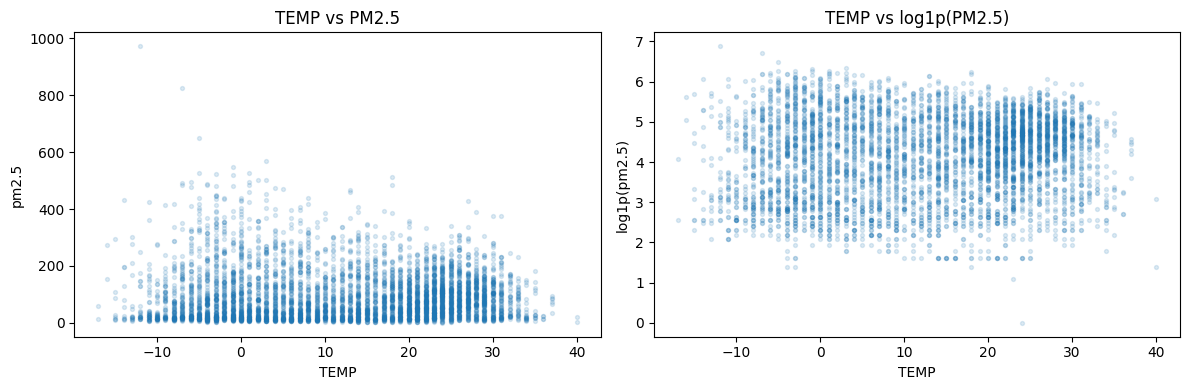

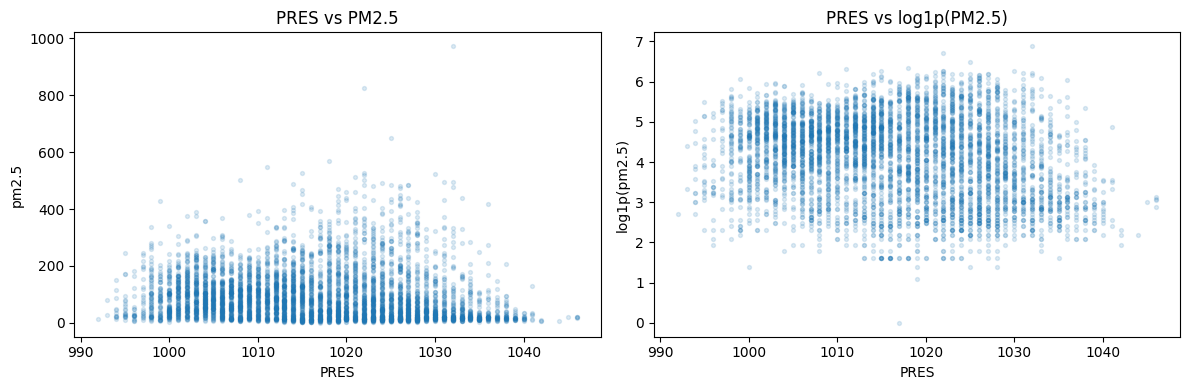

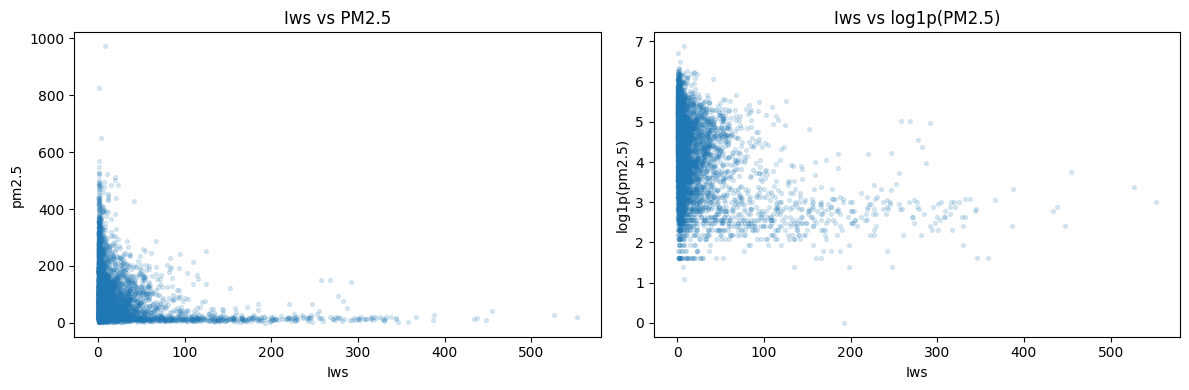

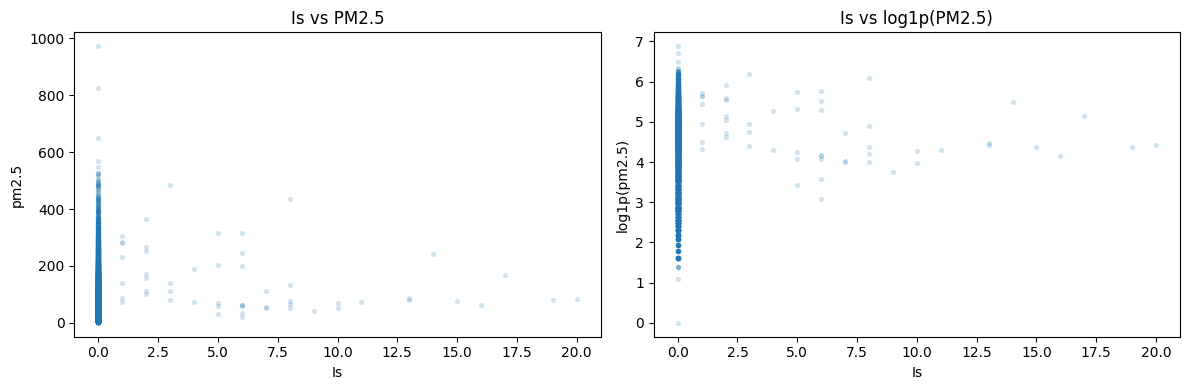

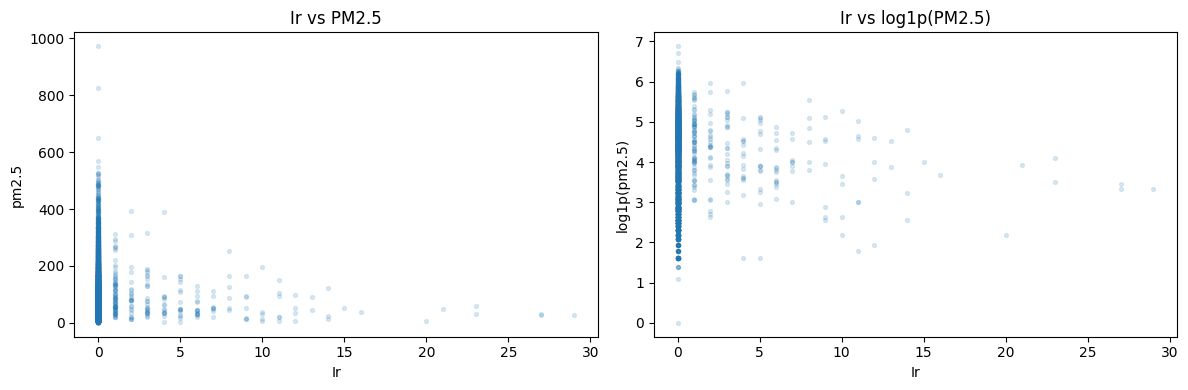

In [13]:
print(' === scatter plot 개선 - 원본 target vs log1p target ===')
print('원본 pm2.5 scatter는 고농도 outlier 때문에 낮은 구간의 구조가 잘 보이지 않을 수 있다.')

# log1p target 생성
# log1p(x) = log(1+x)
# pm2.5에 0이 있으므로 log(x)보다 log1p(x)가 안전하다.
train_df['pm2.5_log1p'] = np.log1p(train_df[target])

# 시각화용 샘플
train_sample = train_df.sample(
    n=min(5000, len(train_df)),
    random_state=3085
)

for col in numeric_weather_features:
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.scatter(train_sample[col], train_sample[target], alpha=0.15, s=8)
    plt.title(f'{col} vs PM2.5')
    plt.xlabel(col)
    plt.ylabel('pm2.5')
    
    plt.subplot(1, 2, 2)
    plt.scatter(train_sample[col], train_sample['pm2.5_log1p'], alpha=0.15, s=8)
    plt.title(f'{col} vs log1p(PM2.5)')
    plt.xlabel(col)
    plt.ylabel('log1p(pm2.5)')
    
    plt.tight_layout()
    plt.show()

 === month별 주요 feature 상관계수 ===


,month,feature,pearson_corr,pearson_p_value,spearman_corr,spearman_p_value
1,1,DEWP,0.655966,0.000000e+00,0.730731,0.000000e+00
5,2,DEWP,0.622824,3.356228e-291,0.727386,0.000000e+00
9,3,DEWP,0.682816,0.000000e+00,0.778685,0.000000e+00
13,4,DEWP,0.591549,1.776868e-271,0.645639,0.000000e+00
17,5,DEWP,0.575635,2.952901e-262,0.652309,0.000000e+00
21,6,DEWP,0.524983,9.003273e-204,0.545665,3.435663e-223
25,7,DEWP,0.599467,6.637310e-290,0.640294,0.000000e+00
29,8,DEWP,0.412377,1.499189e-122,0.468686,2.061305e-162
33,9,DEWP,0.526335,5.323977e-205,0.650071,0.000000e+00
37,10,DEWP,0.589943,1.404251e-278,0.622828,0.000000e+00


 === B4-9-3단계 : month별 Spearman correlation 변화 ===


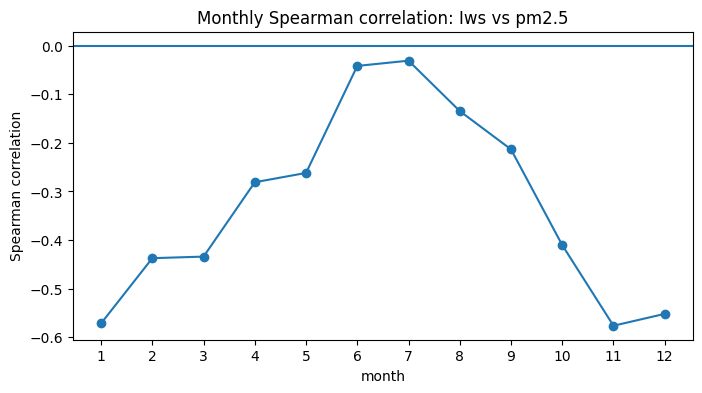

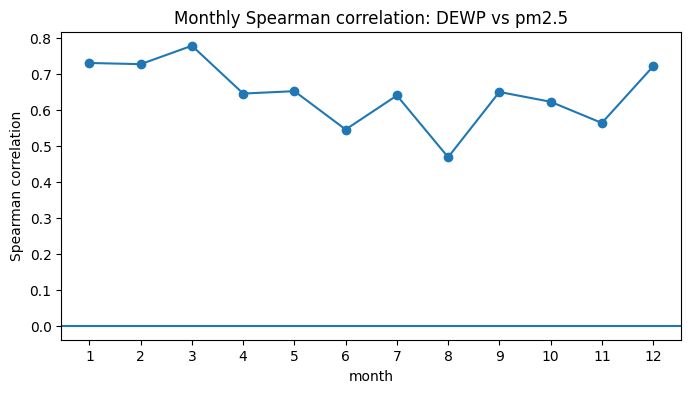

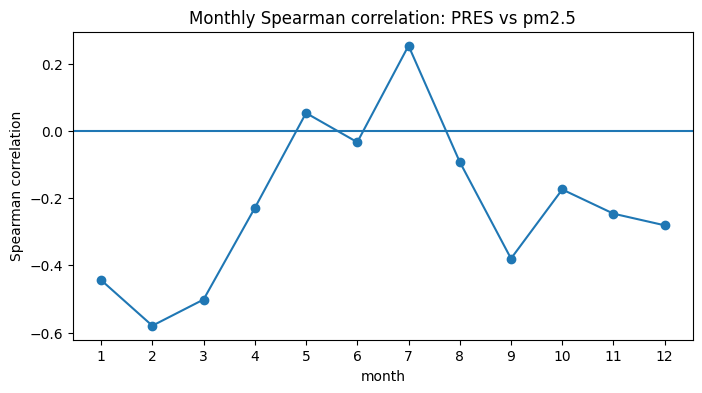

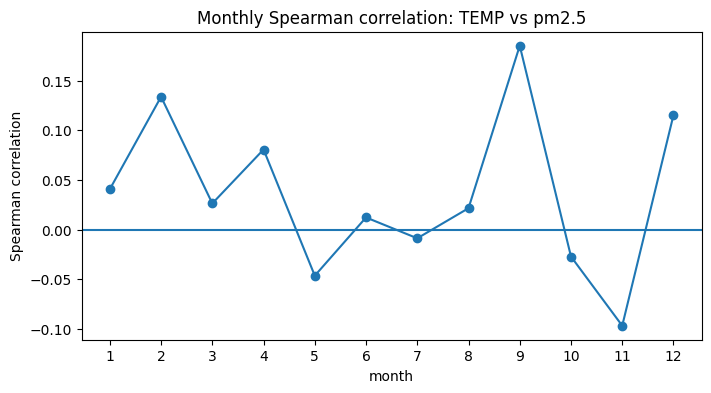

In [14]:
print(' === month별 주요 feature 상관계수 ===')

month_corr_rows = []

for month_value, group in train_df.groupby('month'):
    for col in ['Iws', 'DEWP', 'PRES', 'TEMP']:
        if group[col].nunique() > 1 and group[target].nunique() > 1:
            pearson_corr, pearson_p = pearsonr(group[col], group[target])
            spearman_corr, spearman_p = spearmanr(group[col], group[target])
            
            month_corr_rows.append({
                'month': month_value,
                'feature': col,
                'pearson_corr': pearson_corr,
                'pearson_p_value': pearson_p,
                'spearman_corr': spearman_corr,
                'spearman_p_value': spearman_p
            })

month_corr_result = pd.DataFrame(month_corr_rows)

display(month_corr_result.sort_values(['feature', 'month']))

print(' === B4-9-3단계 : month별 Spearman correlation 변화 ===')

for col in ['Iws', 'DEWP', 'PRES', 'TEMP']:
    temp_plot = month_corr_result[month_corr_result['feature'] == col]
    
    plt.figure(figsize=(8, 4))
    plt.plot(temp_plot['month'], temp_plot['spearman_corr'], marker='o')
    plt.axhline(0)
    plt.title(f'Monthly Spearman correlation: {col} vs pm2.5')
    plt.xlabel('month')
    plt.ylabel('Spearman correlation')
    plt.xticks(range(1, 13))
    plt.show()

 === 핵심 feature Iws, DEWP 집중 분석 ===

=== Iws 집중 분석 ===
                Iws         pm2.5   pm2.5_log1p
count  35064.000000  35064.000000  35064.000000
mean      24.956033     97.782883      4.156130
std       51.300274     90.748846      1.005972
min        0.450000      0.000000      0.000000
25%        1.790000     29.000000      3.401197
50%        5.810000     72.000000      4.290459
75%       23.250000    137.000000      4.927254
max      585.600000    994.000000      6.902743


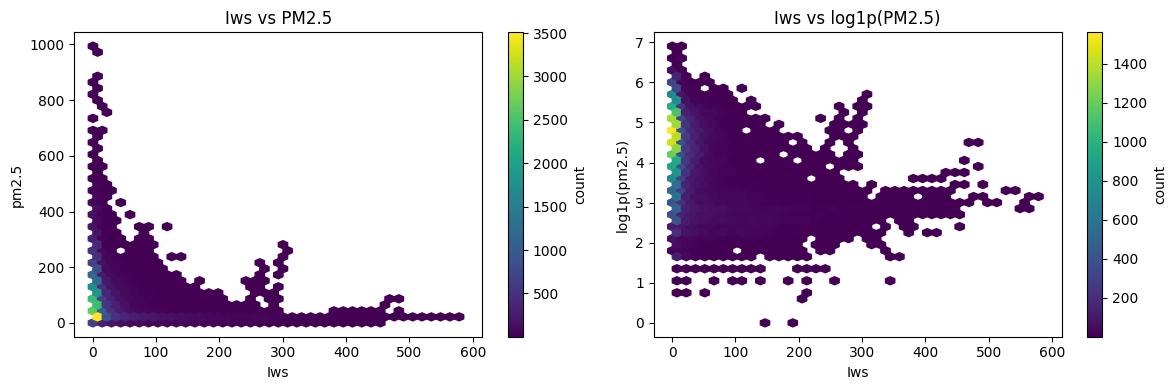


=== DEWP 집중 분석 ===
               DEWP         pm2.5   pm2.5_log1p
count  35064.000000  35064.000000  35064.000000
mean       1.758556     97.782883      4.156130
std       14.499931     90.748846      1.005972
min      -33.000000      0.000000      0.000000
25%      -11.000000     29.000000      3.401197
50%        2.000000     72.000000      4.290459
75%       15.000000    137.000000      4.927254
max       28.000000    994.000000      6.902743


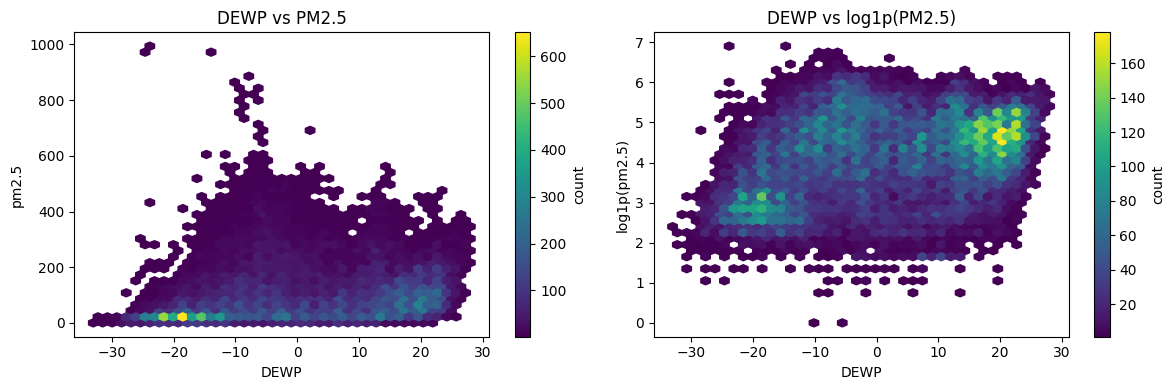

 ===  Iws와 DEWP의 2D 공간에서 pm2.5 보기 ===


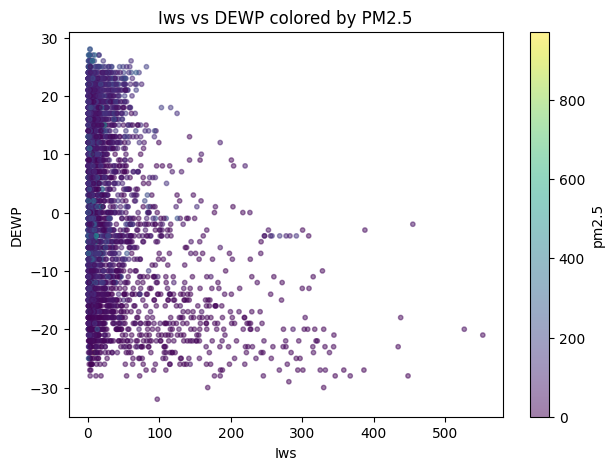

최종 결론:
연속형 기상 feature 중 Iws와 DEWP가 pm2.5와 가장 뚜렷한 관계를 보인다.
Iws는 음의 관계가 가장 강하며, 풍속이 커질수록 오염물질이 확산되어 PM2.5가 낮아지는 패턴으로 해석할 수 있다.
DEWP는 양의 관계가 비교적 강하며, 습하거나 정체된 기상 조건에서 PM2.5가 높아지는 패턴으로 해석할 수 있다.


In [15]:
print(' === 핵심 feature Iws, DEWP 집중 분석 ===')

main_numeric_candidates = ['Iws', 'DEWP']

for col in main_numeric_candidates:
    print(f'\n=== {col} 집중 분석 ===')
    
    print(train_df[[col, target, 'pm2.5_log1p']].describe())
    
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.hexbin(train_df[col], train_df[target], gridsize=40, mincnt=1)
    plt.colorbar(label='count')
    plt.title(f'{col} vs PM2.5')
    plt.xlabel(col)
    plt.ylabel('pm2.5')
    
    plt.subplot(1, 2, 2)
    plt.hexbin(train_df[col], train_df['pm2.5_log1p'], gridsize=40, mincnt=1)
    plt.colorbar(label='count')
    plt.title(f'{col} vs log1p(PM2.5)')
    plt.xlabel(col)
    plt.ylabel('log1p(pm2.5)')
    
    plt.tight_layout()
    plt.show()

print(' ===  Iws와 DEWP의 2D 공간에서 pm2.5 보기 ===')

plt.figure(figsize=(7, 5))

scatter = plt.scatter(
    train_sample['Iws'],
    train_sample['DEWP'],
    c=train_sample[target],
    alpha=0.5,
    s=10
)

plt.colorbar(scatter, label='pm2.5')
plt.title('Iws vs DEWP colored by PM2.5')
plt.xlabel('Iws')
plt.ylabel('DEWP')
plt.show()


print('최종 결론:')
print('연속형 기상 feature 중 Iws와 DEWP가 pm2.5와 가장 뚜렷한 관계를 보인다.')
print('Iws는 음의 관계가 가장 강하며, 풍속이 커질수록 오염물질이 확산되어 PM2.5가 낮아지는 패턴으로 해석할 수 있다.')
print('DEWP는 양의 관계가 비교적 강하며, 습하거나 정체된 기상 조건에서 PM2.5가 높아지는 패턴으로 해석할 수 있다.')

## **PM2.5 데이터 분포 및 주요 변수 요약**

- **PM2.5 분포 특성**
  - 이 데이터의 **PM2.5 값은 정규분포가 아니며**, episode(사건)가 포함된 **오른쪽으로 치우친 분포**를 가진다.

- **분석**
  - 따라서, **고농도 값을 단순 outlier로 간주해 제거하기보다는**  
    **모델이 중요한 이상치를 염두에 두고** 평가하는 것이 중요하다.

- **주요 기상 feature**
  - **연속형 기상 변수(feature) 중**
    - `Iws`와 `DEWP`가 **PM2.5와 가장 밀접한 관계**를 보이는 1차 후보로 선정됨
    - `Iws`는 **음의 관계** (풍속↑ → PM2.5↓, 즉 풍속이 클수록 오염물질이 잘 흩어짐)
    - `DEWP`는 **양의 관계** (이슬점/습도↑ → PM2.5↑, 즉 습하거나 정체된 조건에서 고농도 발생)

- **월별, 계절 특이성**
  - **DEWP는 월별로 나눠도 PM2.5와 안정적으로 양의 상관**을 유지. 특히 DEWP는 단순히 “여름이라 높다/겨울이라 낮다” 수준이 아니라, 같은 월 안에서도 이슬점이 높을수록 PM2.5가 높아지는 경향이 나타남. 이는 이슬점이 높은 습한 대기 조건에서 PM2.5 농도가 높아지는 경향이 있음을 시사함. 핵심 feature 후보로 설정 가능.
  - **Iws는 계절에 따라 효과 강도가 달라지는 특성**을 보임. 이때 Iws는 전체적으로 PM2.5와 음의 관계를 보이며, 특히 겨울·가을에 그 관계가 강함. ->
즉 Iws의 효과는 누적 풍속이 PM2.5 확산 또는 저감과 관련될 가능성이 큼. 계절에 따라 달라지는 피처일 가능성이 있음.

- **후속 모델 설계 방향**
  - 이후 모델링에서는
    - **기상 feature뿐만 아니라**
    - **month / hour / cbwd(풍향 등) 구조까지** 포함하여
    - **시간적 패턴과 기상 조건이 함께 작동하는 PM2.5 예측 문제**로 설계하는 것이 바람직할 것으로 생각된다.

---
# Part B. Baseline 회귀 모델 + 과적합 유발 + 정규화를 통한 과적합 해결 시도 (6점)

## B1. Baseline 모델 구축 및 학습 (3점)

**요구사항**:
- DNN (Dense layer 4개 이상) Baseline 모델 구축
- 과적합을 유도하기 위해 train 데이터의 일부(최대 2000개)만 사용
- `keras.utils.set_random_seed(SEED)` 호출 후 모델 생성
- Adam optimizer, MSE loss, MAE metric
- validation_data로 X_val/y_val 사용
- epochs=50, batch_size=32

**필수 출력**:
- 최종 Train Loss, Val Loss
- Gap (Val - Train) 값


기본 feature:
DEWP, TEMP, PRES, Iws, Is, Ir

시간 feature:
month, hour, dayofweek, is_weekend

풍향 feature:
cbwd_NE, cbwd_NW, cbwd_SE
또는 tree 모델이면 cbwd dummy 전체 사용 가능

핵심 interaction 후보:
Iws × DEWP
Iws × month
DEWP × month
Iws × cbwd

## B1. EDA 기반 모델링 설계

B0 EDA 결과, target `pm2.5`는 평균이 중앙값보다 크고 오른쪽 꼬리가 긴 heavy-tail 분포로 확인되었다. 따라서 고농도 값을 단순 outlier로 제거하기보다, 모델이 고농도 episode를 얼마나 잘 예측하는지 평가해야 한다.

연속형 기상 feature 중에서는 `Iws`와 `DEWP`가 가장 중요한 1차 후보로 나타났다. `DEWP`는 전체 분석과 월별 분석 모두에서 PM2.5와 안정적인 양의 관계를 보였으므로, 비교적 선형적인 설명력을 가진 feature로 해석할 수 있다. 반면 `Iws`는 전체적으로 PM2.5와 음의 관계를 보였지만, 월별로 관계 강도가 달라졌으므로 비선형성 또는 시간 조건과의 상호작용 가능성이 있다.

따라서 본 모델링에서는 단순 선형 모델보다 hidden layer와 ReLU activation을 가진 DNN을 baseline으로 사용한다. DNN은 `DEWP`의 선형적 효과뿐 아니라 `Iws × month`, `Iws × cbwd`, `DEWP × TEMP`, `hour × weather` 같은 feature interaction을 내부 표현으로 학습할 수 있다.

모델링 기준은 다음과 같다.

| 항목 | 설계 |
|---|---|
| 문제 유형 | 회귀(regression) |
| 입력 X | 시간 변수, 기상 변수, 풍향 dummy, 주말 여부 |
| 출력 y | `pm2.5` |
| 출력층 | `Dense(1)` |
| 출력 activation | 없음(linear output) |
| loss | MSE |
| 보조 metric | MAE |
| optimizer | Adam |
| baseline 목적 | 정규화 전 기본 DNN의 train/val loss curve 확인 |
| 이후 비교 | Dropout, L2, EarlyStopping, BatchNorm 개별 적용 |


In [16]:
print(' === B1-1. 공통 유틸 함수 정의 ===')

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 재고정
np.random.seed(SEED)
keras.utils.set_random_seed(SEED)

input_dim = X_train.shape[1]

# B1 요구조건: train 데이터 일부, 최대 2000개만 사용하고 batch_size=32로 학습한다.
# Part C의 공정 비교를 위해 정규화 4개 모델도 같은 subset과 batch size를 사용한다.
TRAIN_SUBSET_SIZE = min(2000, len(X_train))
BATCH_SIZE = 32

rng = np.random.default_rng(SEED)
train_subset_idx = rng.choice(len(X_train), size=TRAIN_SUBSET_SIZE, replace=False)
train_subset_idx = np.sort(train_subset_idx)

X_train_fit = X_train[train_subset_idx]
y_train_fit = y_train[train_subset_idx]

print(f'input_dim: {input_dim}')
print(f'X_train shape: {X_train.shape}')
print(f'X_train_fit shape: {X_train_fit.shape}  # B1 max 2000 subset')
print(f'X_val shape: {X_val.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_train_fit shape: {y_train_fit.shape}')
print(f'y_val shape: {y_val.shape}')
print(f'y_test shape: {y_test.shape}')
print(f'BATCH_SIZE: {BATCH_SIZE}')

def show_last_result(model_name, history):
    """
    history 객체에서 마지막 epoch의 train loss, val loss, gap을 출력한다.
    Part C 요구사항의 Train Loss, Val Loss, Gap 출력에 맞춘 함수.
    """
    train_loss = history.history['loss'][-1]
    val_loss = history.history['val_loss'][-1]
    gap = val_loss - train_loss
    
    print(f'[{model_name}]')
    print(f'Train Loss: {train_loss:.4f}')
    print(f'Val Loss  : {val_loss:.4f}')
    print(f'Gap       : {gap:.4f}')
    
    return {
        'model': model_name,
        'train_loss': train_loss,
        'val_loss': val_loss,
        'gap': gap,
        'epochs': len(history.history['loss'])
    }


def plot_loss_curve(history, title):
    """
    Train Loss와 Val Loss를 한 그래프에 시각화한다.
    Part B 요구사항: 제목, x축, y축, 범례 포함.
    """
    plt.figure(figsize=(8, 5))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel('Loss (MSE)')
    plt.legend()
    plt.show()


def regression_eval(model, X_data, y_data, dataset_name='data'):
    """
    회귀 모델 평가용 함수.
    Keras evaluate의 loss/MAE 외에 RMSE, R²를 함께 계산한다.
    """
    y_pred = model.predict(X_data, verbose=0).reshape(-1)
    
    mae = mean_absolute_error(y_data, y_pred)
    mse = mean_squared_error(y_data, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_data, y_pred)
    
    print(f'=== {dataset_name} regression metrics ===')
    print(f'MAE : {mae:.4f}')
    print(f'MSE : {mse:.4f}')
    print(f'RMSE: {rmse:.4f}')
    print(f'R²  : {r2:.4f}')
    
    return {
        'dataset': dataset_name,
        'mae': mae,
        'mse': mse,
        'rmse': rmse,
        'r2': r2
    }




 === B1-1. 공통 유틸 함수 정의 ===
input_dim: 16
X_train shape: (26294, 16)
X_train_fit shape: (2000, 16)  # B1 max 2000 subset
X_val shape: (8765, 16)
X_test shape: (8765, 16)
y_train shape: (26294,)
y_train_fit shape: (2000,)
y_val shape: (8765,)
y_test shape: (8765,)
BATCH_SIZE: 32


 === B2. Baseline DNN 모델 학습 ===


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,713 (14.50 KB)

 Trainable params: 3,713 (14.50 KB)

 Non-trainable params: 0 (0.00 B)

[Baseline]
Train Loss: 3994.2639
Val Loss  : 5263.4839
Gap       : 1269.2200


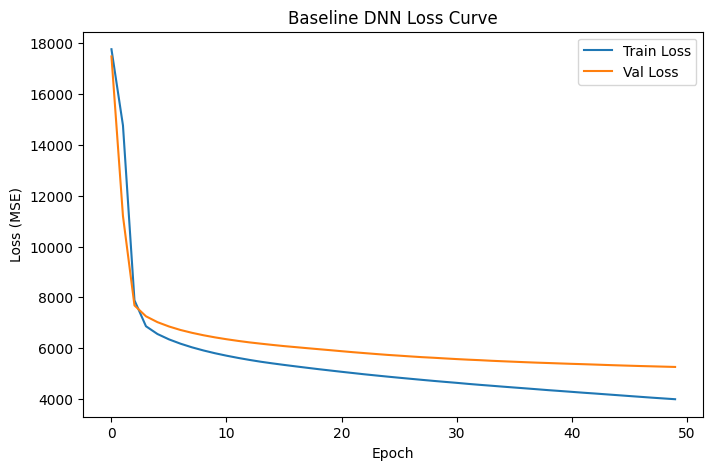

In [17]:
print(' === B2. Baseline DNN 모델 학습 ===')
def build_baseline_model():
    model = Sequential()
    
    # Dense + ReLU
    # DEWP의 선형/준선형 효과와 Iws의 비선형 패턴을 hidden layer에서 함께 학습하게 한다.
    model.add(Dense(64, activation='relu', input_shape=(input_dim,)))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(16, activation='relu'))
    
    # 회귀 출력층: pm2.5는 연속값이므로 activation을 두지 않는다.
    model.add(Dense(1))
    
    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )
    
    return model


baseline_model = build_baseline_model()

baseline_model.summary()

baseline_history = baseline_model.fit(
    X_train_fit, y_train_fit,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=BATCH_SIZE,
    verbose=0
)

baseline_result = show_last_result('Baseline', baseline_history) 

plot_loss_curve(baseline_history, 'Baseline DNN Loss Curve')


## B2. Loss Curve 시각화 + 과적합 분석 (3점)

**요구사항**:
- Train Loss와 Val Loss를 한 그래프에 시각화
- 그래프 제목, x/y 축 라벨, 범례 모두 포함

**분석 (마크다운으로 작성)**:
- Loss curve를 보고 과적합이 발생했는지 판단하라
- 어떤 신호로 과적합을 판단했는지 설명


**모델링**:
- Baseline DNN은 Dense(64) → Dense(32) → Dense(16) → Dense(1) 구조로 구성했다.
- B1 요구조건에 맞춰 train 데이터 전체가 아니라 `X_train_fit/y_train_fit` 2000개 subset만 사용했고, `batch_size=32`로 학습했다.
- 입력 feature는 16개이고, target은 연속형 pm2.5이므로 출력층은 activation이 없는 Dense(1)로 두었다.
- Hidden layer에는 ReLU를 사용해 DEWP의 비교적 안정적인 관계와 Iws의 비선형 패턴을 함께 학습하도록 설계했다.

**분석**:
- Loss curve
    - train loss와 validation loss의 진행 방향을 함께 보고, 마지막 epoch 기준 Train Loss, Val Loss, Gap을 바로 위 B2 출력값으로 판단한다.
    - B1은 일부 train subset으로 과적합 가능성을 유도하는 실험이므로, 전체 train set 학습보다 train-validation gap이 커질 수 있다.
    - validation loss가 계속 내려가면 추가 학습 여지가 있고, validation loss가 상승하면 과적합 신호로 해석한다.

- Validation
    - MAE, RMSE, R²는 바로 위 validation prediction check의 최신 출력값을 기준으로 해석한다.
    - Actual vs Predicted와 residual plot에서는 모델이 전체 경향을 학습했는지, 예측값이 중앙 범위로 압축되는지, 고농도 구간을 과소예측하는지 확인한다.
    - 농도 구간별 오차 분석에서는 low/mid/high/extreme bin에서 MAE와 mean residual이 어떻게 달라지는지가 핵심이다.

**결론 및 향후 모델링 방향성**:
- Baseline DNN은 B1 요구조건을 만족하는 기준 모델이다.
- Part C에서는 Dropout, L2 Regularization, EarlyStopping, Batch Normalization을 같은 subset과 같은 batch size 조건에서 각각 개별 적용해 validation loss, train-validation gap, 고농도 구간 오차가 개선되는지 비교한다.


 === B2-1. Baseline Loss Curve + Best Epoch ===
Best epoch    : 50
Train Loss    : 3994.2639
Val Loss      : 5263.4839
Gap           : 1269.2200
Train MAE     : 44.8329
Val MAE       : 51.0481
Val RMSE      : 72.5499


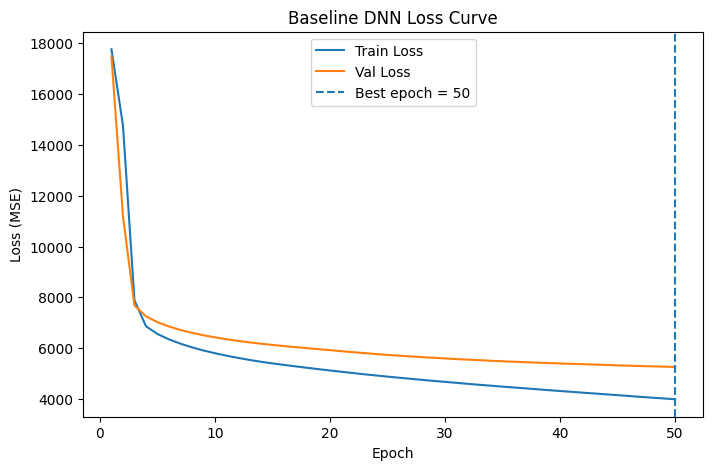

Loss curve를 보면 train loss와 validation loss가 모두 epoch가 증가함에 따라 감소한다. Best epoch는 50일때, Validation loss가 상승하지 않았으므로 강한 과적합은 관찰되지 않는다.
따라서 모델이 train set에 더 잘 맞는 약한 generalization gap은 존재한다


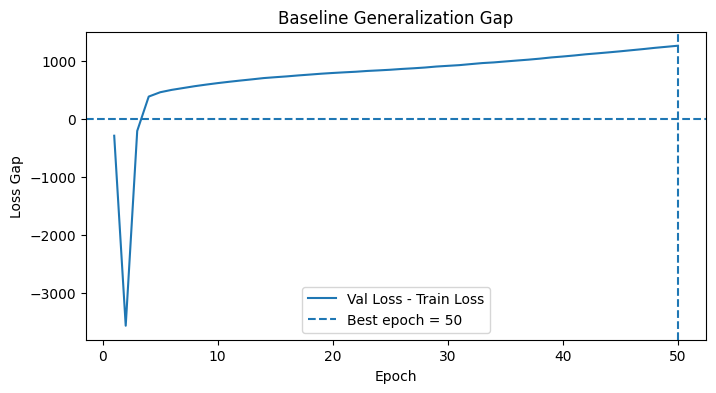

다만 train loss가 validation loss보다 지속적으로 낮고, 마지막 기준 train loss는 약 3994.3, validation loss는 약 5263.5, gap은 약 1269.2이다.
따라서 2000개 subset 학습 조건에서는 train set에 더 잘 맞는 generalization gap이 존재한다.
== 단, validation loss가 상승하는 패턴보다는 train/validation loss가 함께 감소하는 패턴이므로, 강한 과적합이라기보다 subset 학습에서 발생한 일반화 gap으로 판단한다. ==


In [18]:
print(' === B2-1. Baseline Loss Curve + Best Epoch ===')

baseline_epoch_df = pd.DataFrame({
    'epoch': np.arange(1, len(baseline_history.history['loss']) + 1),
    'train_loss': baseline_history.history['loss'],
    'val_loss': baseline_history.history['val_loss'],
    'train_mae': baseline_history.history['mae'],
    'val_mae': baseline_history.history['val_mae']
})

baseline_epoch_df['loss_gap'] = baseline_epoch_df['val_loss'] - baseline_epoch_df['train_loss']

best_idx = baseline_epoch_df['val_loss'].idxmin()
best_row = baseline_epoch_df.loc[best_idx]
best_epoch = int(best_row['epoch'])

print(f"Best epoch    : {best_epoch}")
print(f"Train Loss    : {best_row['train_loss']:.4f}")
print(f"Val Loss      : {best_row['val_loss']:.4f}")
print(f"Gap           : {best_row['loss_gap']:.4f}")
print(f"Train MAE     : {best_row['train_mae']:.4f}")
print(f"Val MAE       : {best_row['val_mae']:.4f}")
print(f"Val RMSE      : {np.sqrt(best_row['val_loss']):.4f}")

plt.figure(figsize=(8, 5))
plt.plot(baseline_epoch_df['epoch'], baseline_epoch_df['train_loss'], label='Train Loss')
plt.plot(baseline_epoch_df['epoch'], baseline_epoch_df['val_loss'], label='Val Loss')
plt.axvline(best_epoch, linestyle='--', label=f'Best epoch = {best_epoch}')
plt.title('Baseline DNN Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()
print('Loss curve를 보면 train loss와 validation loss가 모두 epoch가 증가함에 따라 감소한다. Best epoch는 50일때, Validation loss가 상승하지 않았으므로 강한 과적합은 관찰되지 않는다.')
print('따라서 모델이 train set에 더 잘 맞는 약한 generalization gap은 존재한다')

plt.figure(figsize=(8, 4))
plt.plot(baseline_epoch_df['epoch'], baseline_epoch_df['loss_gap'], label='Val Loss - Train Loss')
plt.axhline(0, linestyle='--')
plt.axvline(best_epoch, linestyle='--', label=f'Best epoch = {best_epoch}')
plt.title('Baseline Generalization Gap')
plt.xlabel('Epoch')
plt.ylabel('Loss Gap')
plt.legend()
plt.show()

print(f'다만 train loss가 validation loss보다 지속적으로 낮고, 마지막 기준 train loss는 약 {best_row["train_loss"]:.1f}, validation loss는 약 {best_row["val_loss"]:.1f}, gap은 약 {best_row["loss_gap"]:.1f}이다.')
print('따라서 2000개 subset 학습 조건에서는 train set에 더 잘 맞는 generalization gap이 존재한다.')
print('== 단, validation loss가 상승하는 패턴보다는 train/validation loss가 함께 감소하는 패턴이므로, 강한 과적합이라기보다 subset 학습에서 발생한 일반화 gap으로 판단한다. ==')


 === B2-2. Baseline Validation Prediction Check ===


MAE : 51.0481
MSE : 5263.4834
RMSE: 72.5499
R²  : 0.3859


,y_true,y_pred,residual,abs_error
count,8765.000000,8765.000000,8765.000000,8765.000000
mean,98.154823,100.019035,-1.864221,51.048088
std,92.585632,62.285843,72.530052,51.554626
min,1.000000,-3.687966,-214.950775,0.018097
25%,28.000000,51.823105,-44.349060,15.135445
50%,71.000000,100.486534,-6.348734,36.195206
75%,136.000000,141.693863,25.427608,70.425262
max,980.000000,343.845123,912.366272,912.366272


Validation 성능은 MAE 약 51.05, RMSE 약 72.55, R² 약 0.386로 나타났다.


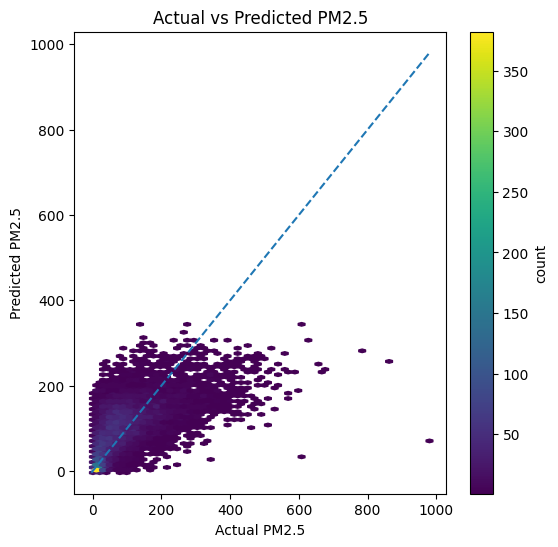

Actual vs Predicted와 residual plot을 보면 모델은 전체 경향은 학습했지만, 예측값이 중앙 범위로 압축되는 경향이 있다


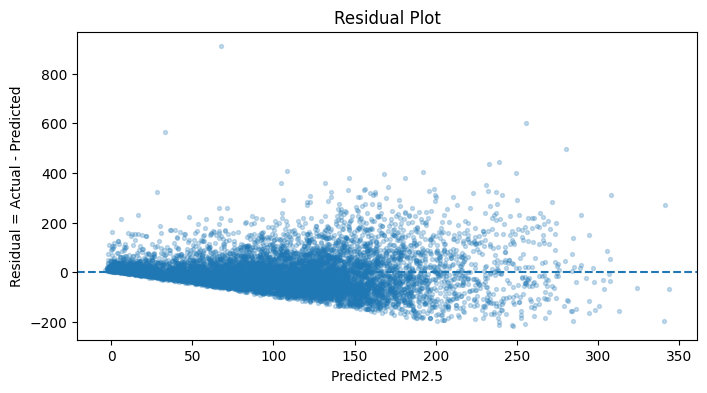

== 이는 baseline DNN이 PM2.5 변동의 일부를 설명하고 있으나, 고농도 episode까지 충분히 정밀하게 맞히지는 못한다는 의미다. ==


In [19]:
print(' === B2-2. Baseline Validation Prediction Check ===')

y_val_pred = baseline_model.predict(X_val, verbose=0).reshape(-1)

val_residual = y_val - y_val_pred
val_abs_error = np.abs(val_residual)

baseline_val_eval = pd.DataFrame({
    'y_true': y_val,
    'y_pred': y_val_pred,
    'residual': val_residual,
    'abs_error': val_abs_error
})

val_mae = mean_absolute_error(y_val, y_val_pred)
val_mse = mean_squared_error(y_val, y_val_pred)
val_rmse = np.sqrt(val_mse)
val_r2 = r2_score(y_val, y_val_pred)

print(f"MAE : {val_mae:.4f}")
print(f"MSE : {val_mse:.4f}")
print(f"RMSE: {val_rmse:.4f}")
print(f"R²  : {val_r2:.4f}")

display(baseline_val_eval.describe())

print(f'Validation 성능은 MAE 약 {val_mae:.2f}, RMSE 약 {val_rmse:.2f}, R² 약 {val_r2:.3f}로 나타났다.')

min_value = min(y_val.min(), y_val_pred.min())
max_value = max(y_val.max(), y_val_pred.max())

plt.figure(figsize=(6, 6))
plt.hexbin(y_val, y_val_pred, gridsize=50, mincnt=1)
plt.colorbar(label='count')
plt.plot([min_value, max_value], [min_value, max_value], linestyle='--')
plt.title('Actual vs Predicted PM2.5')
plt.xlabel('Actual PM2.5')
plt.ylabel('Predicted PM2.5')
plt.show()

print('Actual vs Predicted와 residual plot을 보면 모델은 전체 경향은 학습했지만, 예측값이 중앙 범위로 압축되는 경향이 있다')
plt.figure(figsize=(8, 4))
plt.scatter(y_val_pred, val_residual, alpha=0.25, s=8)
plt.axhline(0, linestyle='--')
plt.title('Residual Plot')
plt.xlabel('Predicted PM2.5')
plt.ylabel('Residual = Actual - Predicted')
plt.show()

print('== 이는 baseline DNN이 PM2.5 변동의 일부를 설명하고 있으나, 고농도 episode까지 충분히 정밀하게 맞히지는 못한다는 의미다. ==')


 === B2-3. PM2.5 농도구간별오차. (categorical로 치환)===


,count,y_true_mean,y_pred_mean,mae,residual_mean,bias
pm25_bin,,,,,,
low_<50%,4345,32.170311,64.850098,41.171467,-32.679790,overprediction
mid_50-75%,2215,99.531830,115.733360,38.311584,-16.201534,overprediction
high_75-95%,1765,190.954681,144.801163,58.694447,46.153500,underprediction
extreme_>=95%,440,370.565918,188.567612,182.024124,181.998291,underprediction


== 농도 구간별 오차 분석에서 저농도 구간은 과대예측하고, 고농도 extreme 구간은 과소예측하는 패턴이 나타났다. ==


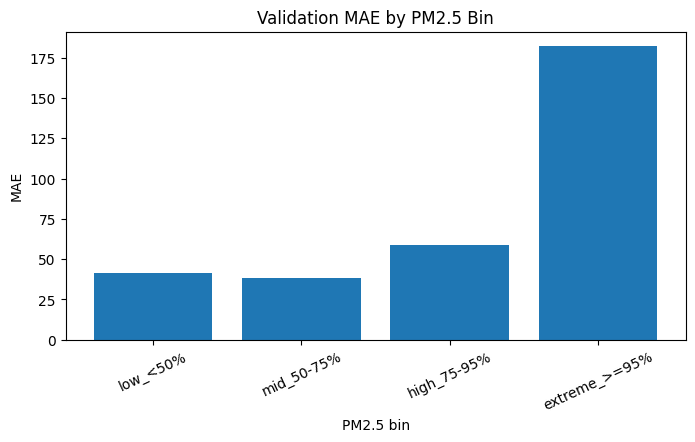

===  따라서 Baseline DNN은 강한 과적합 모델은 아니지만, 저농도, 특히 고농도 PM2.5 episode를 충분히 잡지 못하는 한계가 있다. ===


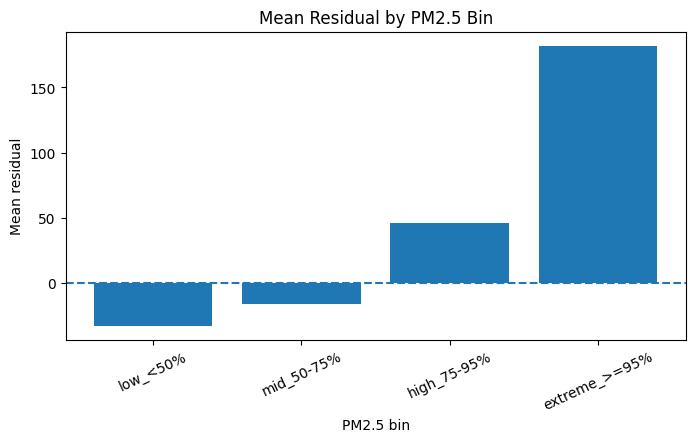

 ==> 이에 대하여 Part C에서는 Dropout, L2 Regularization, EarlyStopping, Batch Normalization을 각각 개별 적용하여,
validation loss, train-validation gap, 그리고 고농도 구간 오차가 개선되는지를 중점적으로 비교함이 적절할 것으로 판단된다. ==


In [20]:
print(' === B2-3. PM2.5 농도구간별오차. (categorical로 치환)===')

q50 = np.quantile(y_val, 0.50)
q75 = np.quantile(y_val, 0.75)
q95 = np.quantile(y_val, 0.95)

def pm25_bin(x):
    if x < q50:
        return 'low_<50%'
    elif x < q75:
        return 'mid_50-75%'
    elif x < q95:
        return 'high_75-95%'
    else:
        return 'extreme_>=95%'

bin_order = ['low_<50%', 'mid_50-75%', 'high_75-95%', 'extreme_>=95%']

baseline_val_eval['pm25_bin'] = baseline_val_eval['y_true'].apply(pm25_bin)
baseline_val_eval['pm25_bin'] = pd.Categorical(
    baseline_val_eval['pm25_bin'],
    categories=bin_order,
    ordered=True
)

bin_error = baseline_val_eval.groupby('pm25_bin', observed=False).agg(
    count=('y_true', 'count'),
    y_true_mean=('y_true', 'mean'),
    y_pred_mean=('y_pred', 'mean'),
    mae=('abs_error', 'mean'),
    residual_mean=('residual', 'mean')
)

bin_error['bias'] = np.where(
    bin_error['residual_mean'] > 0,
    'underprediction',
    'overprediction'
)

display(bin_error)
print('== 농도 구간별 오차 분석에서 저농도 구간은 과대예측하고, 고농도 extreme 구간은 과소예측하는 패턴이 나타났다. ==')


plt.figure(figsize=(8, 4))
plt.bar(bin_error.index, bin_error['mae'])
plt.title('Validation MAE by PM2.5 Bin')
plt.xlabel('PM2.5 bin')
plt.ylabel('MAE')
plt.xticks(rotation=25)
plt.show()

print('===  따라서 Baseline DNN은 강한 과적합 모델은 아니지만, 저농도, 특히 고농도 PM2.5 episode를 충분히 잡지 못하는 한계가 있다. ===')

plt.figure(figsize=(8, 4))
plt.bar(bin_error.index, bin_error['residual_mean'])
plt.axhline(0, linestyle='--')
plt.title('Mean Residual by PM2.5 Bin')
plt.xlabel('PM2.5 bin')
plt.ylabel('Mean residual')
plt.xticks(rotation=25)
plt.show()

print(' ==> 이에 대하여 Part C에서는 Dropout, L2 Regularization, EarlyStopping, Batch Normalization을 각각 개별 적용하여,')
print('validation loss, train-validation gap, 그리고 고농도 구간 오차가 개선되는지를 중점적으로 비교함이 적절할 것으로 판단된다. ==')

---
# Part C. 정규화 4총사 각각 적용 (14점)

Part B와 같은 조건(같은 데이터, 같은 학습 설정)에서
*각 정규화 기법을 개별적으로* 적용해 효과를 비교하세요.



**B 요약 및 C 모델링 방향성**:
- Baseline 모델은 과적합이 심한 모델이 아니며, 정상적으로 학습 중이지만 저/고농도 값에 대해 성능이 다소 부족한 문제가 발생하였다.

- 따라서 C파트의 목적은 단순히 train loss를 낮추는 것이 아니라 validation 일반화와 고농도 구간 예측 취약점이 개선되는지 확인하는 것이다.



In [21]:
print(' === C0. 정규화 GLOBAL 설정 ===')

regularization_results = []
regularization_histories = {}

def get_last_result(model_name, history):
    train_loss = history.history['loss'][-1]
    val_loss = history.history['val_loss'][-1]
    gap = val_loss - train_loss
    
    train_mae = history.history['mae'][-1]
    val_mae = history.history['val_mae'][-1]
    
    print(f'[{model_name}]')
    print(f'Train Loss: {train_loss:.4f}')
    print(f'Val Loss  : {val_loss:.4f}')
    print(f'Gap       : {gap:.4f}')
    print(f'Train MAE : {train_mae:.4f}')
    print(f'Val MAE   : {val_mae:.4f}')
    
    return {
        'model': model_name,
        'train_loss': train_loss,
        'val_loss': val_loss,
        'gap': gap,
        'train_mae': train_mae,
        'val_mae': val_mae,
        'epochs': len(history.history['loss'])
    }

# Baseline도 같은 기준으로 저장
baseline_c_result = get_last_result('Baseline', baseline_history)
regularization_results.append(baseline_c_result)
regularization_histories['Baseline'] = baseline_history

 === C0. 정규화 GLOBAL 설정 ===
[Baseline]
Train Loss: 3994.2639
Val Loss  : 5263.4839
Gap       : 1269.2200
Train MAE : 44.8329
Val MAE   : 51.0481


## C1. Dropout 적용 (3점)

**요구사항**: Baseline 구조에 Dropout(0.3)을 추가
**필수 출력**: Train Loss, Val Loss, Gap

In [22]:
print(' === C1. Dropout(0.3) 적용 ===')

np.random.seed(SEED)
keras.utils.set_random_seed(SEED)

def build_dropout_model():
    model = Sequential()
    model.add(Dense(64, activation='relu', input_shape=(input_dim,)))
    model.add(Dropout(0.3))
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(16, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(1))
    
    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )
    
    return model

dropout_model = build_dropout_model()

dropout_history = dropout_model.fit(
    X_train_fit, y_train_fit,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=BATCH_SIZE,
    verbose=0
)

dropout_result = get_last_result('Dropout', dropout_history)

regularization_results.append(dropout_result)
regularization_histories['Dropout'] = dropout_history


 === C1. Dropout(0.3) 적용 ===


[Dropout]
Train Loss: 6002.7637
Val Loss  : 5742.8447
Gap       : -259.9189
Train MAE : 53.6394
Val MAE   : 52.5151


## C2. L2 Regularization 적용 (3점)

**요구사항**: 모든 Dense 층에 `kernel_regularizer=l2(0.01)`
**필수 출력**: Train Loss, Val Loss, Gap

In [23]:
print(' === C2. L2 Regularization 적용 ===')

np.random.seed(SEED)
keras.utils.set_random_seed(SEED)

def build_l2_model():
    model = Sequential()
    
    model.add(Dense(64, activation='relu', kernel_regularizer=l2(0.01), input_shape=(input_dim,)))
    model.add(Dense(32, activation='relu', kernel_regularizer=l2(0.01)))
    model.add(Dense(16, activation='relu', kernel_regularizer=l2(0.01)))
    model.add(Dense(1, kernel_regularizer=l2(0.01)))
    
    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )
    
    return model

l2_model = build_l2_model()

l2_history = l2_model.fit(
    X_train_fit, y_train_fit,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=BATCH_SIZE,
    verbose=0
)

l2_result = get_last_result('L2', l2_history)

regularization_results.append(l2_result)
regularization_histories['L2'] = l2_history


 === C2. L2 Regularization 적용 ===


[L2]
Train Loss: 4042.7578
Val Loss  : 5251.4712
Gap       : 1208.7134
Train MAE : 45.0991
Val MAE   : 51.0716


## C3. Early Stopping 적용 (3점)

**요구사항**:
- `EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)`
- epochs는 50보다 크게 잡아도 됨 (Early Stop이 멈춤)

**필수 출력**:
- Train Loss, Val Loss, Gap
(* 강의의 train_and_eval과 동일하게, history.history['val_loss'][-1](마지막 epoch의 val_loss)을 출력하시오.)
- 실제 학습된 epoch 수

In [24]:
print(' === C3. Early Stopping 적용 ===')

np.random.seed(SEED)
keras.utils.set_random_seed(SEED)

def build_earlystop_model():
    model = Sequential()
    
    model.add(Dense(64, activation='relu', input_shape=(input_dim,)))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(16, activation='relu'))
    model.add(Dense(1))
    
    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )
    
    return model

earlystop_model = build_earlystop_model()

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

earlystop_history = earlystop_model.fit(
    X_train_fit, y_train_fit,
    validation_data=(X_val, y_val),
    epochs=150,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=0
)

earlystop_result = get_last_result('EarlyStopping', earlystop_history)

print(f"실제 학습된 epoch 수: {len(earlystop_history.history['loss'])}")

regularization_results.append(earlystop_result)
regularization_histories['EarlyStopping'] = earlystop_history


 === C3. Early Stopping 적용 ===


[EarlyStopping]
Train Loss: 2647.9390
Val Loss  : 5022.9136
Gap       : 2374.9746
Train MAE : 36.6457
Val MAE   : 49.0036
실제 학습된 epoch 수: 115


## C4. Batch Normalization 적용 (3점)

**요구사항**:
- `Dense → BatchNorm → Activation` 순서로 구성
- 활성화 함수는 Dense의 인자가 아닌 별도 `Activation('relu')`로

**필수 출력**: Train Loss, Val Loss, Gap

In [25]:
print(' === C4. Batch Normalization 적용 ===')

np.random.seed(SEED)
keras.utils.set_random_seed(SEED)

def build_batchnorm_model():
    model = Sequential()
    
    model.add(Dense(64, input_shape=(input_dim,)))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    
    model.add(Dense(32))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    
    model.add(Dense(16))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    
    model.add(Dense(1))
    
    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )
    
    return model

batchnorm_model = build_batchnorm_model()

batchnorm_history = batchnorm_model.fit(
    X_train_fit, y_train_fit,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=BATCH_SIZE,
    verbose=0
)

batchnorm_result = get_last_result('BatchNorm', batchnorm_history)

regularization_results.append(batchnorm_result)
regularization_histories['BatchNorm'] = batchnorm_history


 === C4. Batch Normalization 적용 ===


[BatchNorm]
Train Loss: 1473.8469
Val Loss  : 9147.0645
Gap       : 7673.2175
Train MAE : 27.8435
Val MAE   : 58.9086


## C5. 4가지 비교 시각화 (2점)

Baseline + 4총사 (5개 모델)의 loss curve를 비교 그래프로 시각화.

**요약**
- Baseline, Dropout, L2 Regularization, EarlyStopping, Batch Normalization을 같은 train subset, 같은 train/validation split, 같은 `batch_size=32` 조건에서 비교했다.
- 비교 기준은 validation loss, validation MAE, gap = validation loss - train loss, 그리고 loss curve의 안정성이다.

- 주안: B2에서 Baseline은 `train subset 2000개`만 사용한 기준 모델이므로 train-validation gap과 고농도 PM2.5 과소예측 여부를 반드시 확인해야 한다.
- 따라서 Part C의 목적은 단순히 train loss를 낮추는 것이 아니라, validation 기준 일반화 성능과 예측 안정성이 Baseline 대비 개선되는지 확인하는 것이다.

**Validation loss curve**
- 최신 수치는 바로 아래 C5 결과표를 기준으로 한다.
- C5에서는 `val_loss`를 1순위, `val_mae`를 2순위, `gap_abs`를 보조 기준으로 정렬한다.
- Baseline보다 validation loss가 낮고, validation MAE도 낮으며, gap 해석이 가능한 모델을 최종 후보로 선택한다.

**결론**
- 최종 후보는 C5의 `selection_df` 1행에 있는 모델이다.
- 단, validation 기준 후보가 test set에서도 실제 일반화되는지는 Part D에서 Baseline 대비 test metric, residual, 농도 구간별 MAE로 다시 검증한다.


In [26]:
print(' === C5-1. 정규화 5개 모델 결과표 정리 ===')

# 여러 번 실행했을 경우 같은 model이 중복 저장될 수 있으므로 마지막 결과만 사용
regularization_result_df = pd.DataFrame(regularization_results).drop_duplicates(
    subset='model',
    keep='last'
).copy()

model_order = ['Baseline', 'Dropout', 'L2', 'EarlyStopping', 'BatchNorm']
model_order = [m for m in model_order if m in regularization_result_df['model'].values]

regularization_result_df['model'] = pd.Categorical(
    regularization_result_df['model'],
    categories=model_order,
    ordered=True
)

regularization_result_df = regularization_result_df.sort_values('model').reset_index(drop=True)

# 추가 해석 metric
regularization_result_df['val_rmse'] = np.sqrt(regularization_result_df['val_loss'])
regularization_result_df['gap_abs'] = regularization_result_df['gap'].abs()

baseline_val_loss = regularization_result_df.loc[
    regularization_result_df['model'] == 'Baseline',
    'val_loss'
].iloc[0]

baseline_val_mae = regularization_result_df.loc[
    regularization_result_df['model'] == 'Baseline',
    'val_mae'
].iloc[0]

regularization_result_df['val_loss_delta_vs_baseline'] = (
    regularization_result_df['val_loss'] - baseline_val_loss
)

regularization_result_df['val_loss_improve_pct'] = (
    (baseline_val_loss - regularization_result_df['val_loss']) / baseline_val_loss * 100
)

regularization_result_df['val_mae_delta_vs_baseline'] = (
    regularization_result_df['val_mae'] - baseline_val_mae
)

# 모델별 해석 라벨
diagnosis_map = {
    'Baseline': 'reference',
    'Dropout': 'strong regularization / possible underfit',
    'L2': 'mild regularization',
    'EarlyStopping': 'long training + best epoch search',
    'BatchNorm': 'hidden activation stabilization'
}

regularization_result_df['diagnosis_label'] = regularization_result_df['model'].astype(str).map(diagnosis_map)

display(
    regularization_result_df[
        [
            'model',
            'epochs',
            'train_loss',
            'val_loss',
            'gap',
            'val_mae',
            'val_rmse',
            'val_loss_delta_vs_baseline',
            'val_loss_improve_pct',
            'diagnosis_label'
        ]
    ].sort_values('val_loss')
)

print('해석 기준:')
print('1. val_loss가 낮을수록 validation 기준 회귀 오차가 작음')
print('2. gap = val_loss - train_loss이며, 양수면 validation 손실이 train 손실보다 큰 것으로 판단.')
print('3. Dropout의 gap이 음수 => Train 단계에서 dropout noise가 적용되어 train loss가 더 크게 나올 수 있기 때문임을 유의.')
print('4. 최종 선택은 val_loss를 1순위로 두되, val_mae와 gap을 보조 기준으로 둔다.')

 === C5-1. 정규화 5개 모델 결과표 정리 ===


,model,epochs,train_loss,val_loss,gap,val_mae,val_rmse,val_loss_delta_vs_baseline,val_loss_improve_pct,diagnosis_label
3,EarlyStopping,115,2647.938965,5022.913574,2374.974609,49.003605,70.872516,-240.570312,4.570553,long training + best epoch search
2,L2,50,4042.757812,5251.471191,1208.713379,51.071568,72.467035,-12.012695,0.228227,mild regularization
0,Baseline,50,3994.263916,5263.483887,1269.219971,51.048092,72.549872,0.000000,0.000000,reference
1,Dropout,50,6002.763672,5742.844727,-259.918945,52.515144,75.781559,479.360840,-9.107292,strong regularization / possible underfit
4,BatchNorm,50,1473.846924,9147.064453,7673.217529,58.908566,95.640287,3883.580566,-73.783461,hidden activation stabilization


해석 기준:
1. val_loss가 낮을수록 validation 기준 회귀 오차가 작음
2. gap = val_loss - train_loss이며, 양수면 validation 손실이 train 손실보다 큰 것으로 판단.
3. Dropout의 gap이 음수 => Train 단계에서 dropout noise가 적용되어 train loss가 더 크게 나올 수 있기 때문임을 유의.
4. 최종 선택은 val_loss를 1순위로 두되, val_mae와 gap을 보조 기준으로 둔다.


 === C5-2. 정규화 모델 비교용 결과표 재정리 ===


,abbr,model,epochs,train_loss,val_loss,gap,val_mae,val_rmse,val_loss_improve_pct,diagnosis_label
0,ES,EarlyStopping,115,2647.938965,5022.913574,2374.974609,49.003605,70.872516,4.570553,long training + best epoch search
1,L2,L2,50,4042.757812,5251.471191,1208.713379,51.071568,72.467035,0.228227,mild regularization
2,BL,Baseline,50,3994.263916,5263.483887,1269.219971,51.048092,72.549872,0.000000,reference
3,DO,Dropout,50,6002.763672,5742.844727,-259.918945,52.515144,75.781559,-9.107292,strong regularization / possible underfit
4,BN,BatchNorm,50,1473.846924,9147.064453,7673.217529,58.908566,95.640287,-73.783461,hidden activation stabilization


해석:
C5에서는 val_loss를 1순위 기준으로 모델을 정렬한다.
val_mae는 실제 PM2.5 단위에서 평균적으로 얼마나 틀리는지를 보여주는 보조 기준이다.
gap은 train loss와 validation loss의 차이이므로, 과적합 또는 학습 noise 여부를 판단하는 보조 신호다.
현재 validation 기준 1위 모델은 EarlyStopping이다.


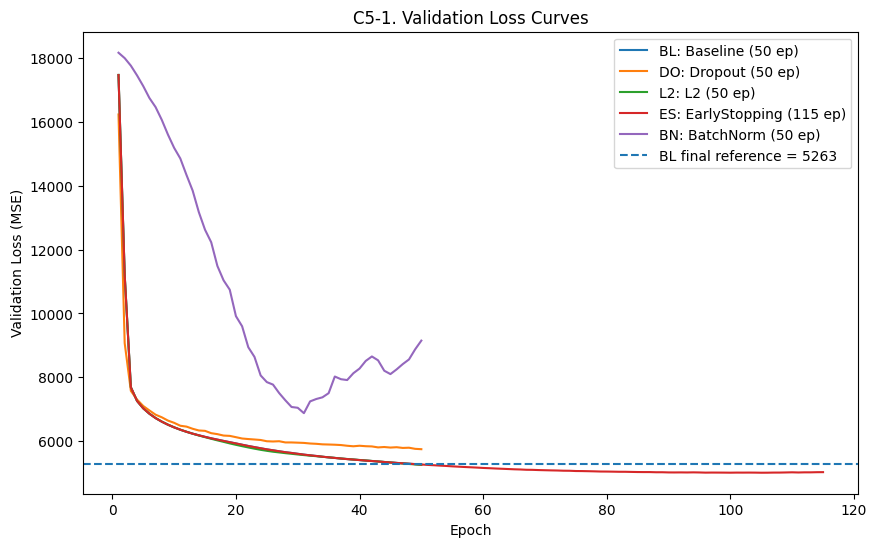

===시각화 1. 해석:===
==Validation loss curve는 각 정규화 전략이 epoch가 진행되면서 일반화 오차를 어떻게 낮추는지 보여준다.==
------------------
=Baseline은 50 epoch 기준 모델이고, EarlyStopping은 115 epoch까지 학습된 뒤 validation 기준 최저 손실을 기록했다.=
따라서 C5의 핵심은 같은 subset 조건에서 어느 정규화 전략이 validation loss를 가장 낮췄는지 비교하는 것이다.
각 정규화 기법의 해석은 아래 결과표의 val_loss, val_mae, gap을 함께 보고 판단한다.
------------------
==결론: validation curve 기준으로는 EarlyStopping이 가장 낮은 일반화 오차를 보인 최종 후보이다.==


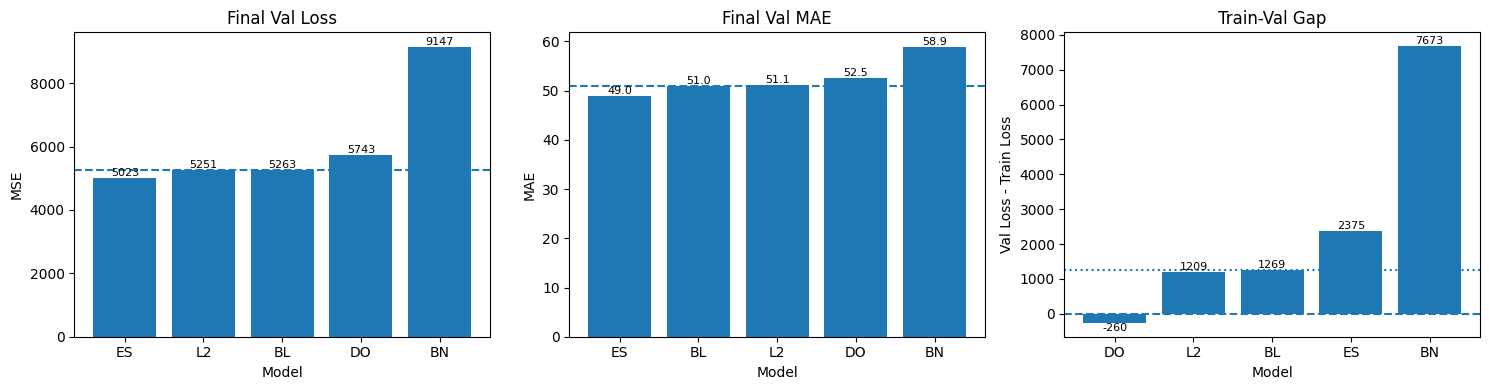

===시각화 2. 해석:===
Final metric dashboard는 validation loss, validation MAE, train-validation gap을 분리해서 보여준다.
Val Loss는 MSE 기준이므로 큰 오차, 특히 고농도 PM2.5 예측 실패에 더 민감하다.
Val MAE는 실제 PM2.5 단위에서 평균적으로 얼마나 틀리는지를 보여주므로 해석이 직관적이다.
Gap은 train과 validation 사이의 차이를 보여주며, 너무 크면 train에 더 잘 맞는 모델일 수 있다.
------------------
===> EarlyStopping은 Val Loss 5022.91, Val MAE 49.00로 validation 기준 1위다.
Baseline 대비 validation loss는 4.57% 개선되었다.===
------------------
Baseline 대비 개선 여부는 각 모델의 val_loss_improve_pct와 val_mae_delta_vs_baseline으로 판단한다.
Dropout은 train 단계 noise 때문에 gap이 음수로 나올 수 있어, val_loss와 val_mae를 함께 보고 underfitting 여부를 판단한다.
 L2는 gap은 안정적인 편이지만 Val Loss 개선율이 0.23%이므로 최종 후보로 보기는 어렵다.
= 다만 EarlyStopping의 gap은 2374.97이고 Baseline gap은 1269.22이므로, D파트에서 test set과 residual 분석으로 실제 일반화 성능을 반드시 확인해야 한다. =


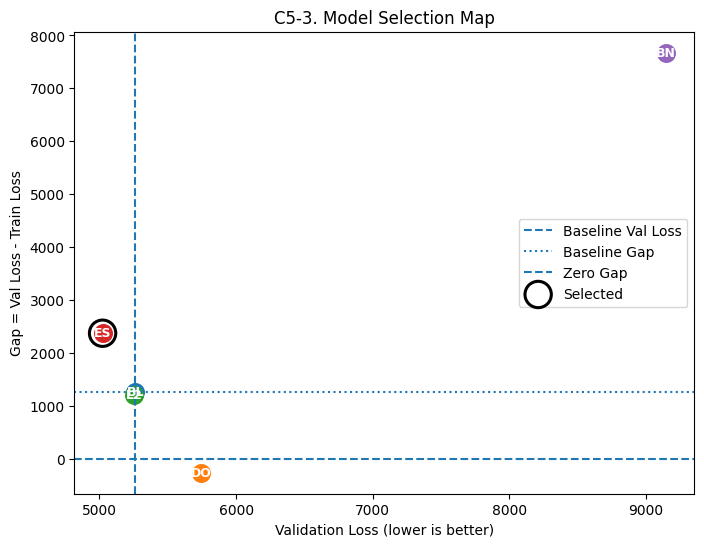

===시각화 결론 해석:===
[validation loss와 train-validation gap을 동시에 보는 시각화 맵]
왼쪽에 있을수록 validation loss가 낮아 성능이 좋고, y=0에 가까울수록 train과 validation 손실 차이가 작다.
Baseline 기준선보다 왼쪽에 있는 모델은 validation loss 기준으로 Baseline보다 개선된 모델이다.
EarlyStopping은 validation loss 기준 가장 낮은 위치에 있으므로 최종 후보로 선택된다
=그러나 EarlyStopping의 gap(2374.97)이 Baseline gap(1269.22)보다 크므로, 성능은 가장 좋지만 gap 보완이 필요한 모델로 해석해야 한다.=
------------------
2순위 후보는 L2이며, val_loss=5251.47, 개선율=0.23%이다.
L2는 gap 안정성과 validation 성능 개선폭을 함께 보고 보수적 후보인지 판단한다.
Dropout은 val_loss 위치와 gap 방향을 함께 보고 최종 후보 포함 여부를 판단한다.

최종 판정:
- Validation 기준 1순위 후보: EarlyStopping
- Val Loss: 5022.9136
- Val MAE : 49.0036
- Gap     : 2374.9746
- Baseline 대비 Val Loss 개선율: 4.57%
----따라서 Part D에서는 *EarlyStopping* 모델을 최종 모델로 선택하고, test set에서 최종 일반화 성능을 평가한다.----


In [27]:
print(' === C5-2. 정규화 모델 비교용 결과표 재정리 ===')

# 여러 번 실행했을 경우 같은 model이 중복 저장될 수 있으므로 마지막 결과만 사용
regularization_result_df = pd.DataFrame(regularization_results).drop_duplicates(
    subset='model',
    keep='last'
).copy()

model_order = ['Baseline', 'Dropout', 'L2', 'EarlyStopping', 'BatchNorm']
model_order = [m for m in model_order if m in regularization_result_df['model'].values]

regularization_result_df['model'] = regularization_result_df['model'].astype(str)
regularization_result_df = regularization_result_df.set_index('model').loc[model_order].reset_index()

# 추가 지표
regularization_result_df['val_rmse'] = np.sqrt(regularization_result_df['val_loss'])
regularization_result_df['gap_abs'] = regularization_result_df['gap'].abs()

baseline_val_loss = regularization_result_df.loc[
    regularization_result_df['model'] == 'Baseline',
    'val_loss'
].iloc[0]

baseline_val_mae = regularization_result_df.loc[
    regularization_result_df['model'] == 'Baseline',
    'val_mae'
].iloc[0]

baseline_gap = regularization_result_df.loc[
    regularization_result_df['model'] == 'Baseline',
    'gap'
].iloc[0]

regularization_result_df['val_loss_delta_vs_baseline'] = (
    regularization_result_df['val_loss'] - baseline_val_loss
)

regularization_result_df['val_loss_improve_pct'] = (
    (baseline_val_loss - regularization_result_df['val_loss']) / baseline_val_loss * 100
)

regularization_result_df['val_mae_delta_vs_baseline'] = (
    regularization_result_df['val_mae'] - baseline_val_mae
)

# 모델 약칭
model_abbr = {
    'Baseline': 'BL',
    'Dropout': 'DO',
    'L2': 'L2',
    'EarlyStopping': 'ES',
    'BatchNorm': 'BN'
}

regularization_result_df['abbr'] = regularization_result_df['model'].map(model_abbr)

# 모델 성격 라벨
diagnosis_map = {
    'Baseline': 'reference',
    'Dropout': 'strong regularization / possible underfit',
    'L2': 'mild regularization',
    'EarlyStopping': 'long training + best epoch search',
    'BatchNorm': 'hidden activation stabilization'
}

regularization_result_df['diagnosis_label'] = regularization_result_df['model'].map(diagnosis_map)

# 선택 기준: val_loss 1순위, val_mae 2순위, gap_abs 3순위
selection_df = regularization_result_df.sort_values(
    ['val_loss', 'val_mae', 'gap_abs'],
    ascending=[True, True, True]
).reset_index(drop=True)

best_model_name = selection_df.loc[0, 'model']
best_model_val_loss = selection_df.loc[0, 'val_loss']
best_model_val_mae = selection_df.loc[0, 'val_mae']
best_model_gap = selection_df.loc[0, 'gap']
best_model_improve_pct = selection_df.loc[0, 'val_loss_improve_pct']

display(
    selection_df[
        [
            'abbr',
            'model',
            'epochs',
            'train_loss',
            'val_loss',
            'gap',
            'val_mae',
            'val_rmse',
            'val_loss_improve_pct',
            'diagnosis_label'
        ]
    ]
)

print('해석:')
print('C5에서는 val_loss를 1순위 기준으로 모델을 정렬한다.')
print('val_mae는 실제 PM2.5 단위에서 평균적으로 얼마나 틀리는지를 보여주는 보조 기준이다.')
print('gap은 train loss와 validation loss의 차이이므로, 과적합 또는 학습 noise 여부를 판단하는 보조 신호다.')
print(f'현재 validation 기준 1위 모델은 {best_model_name}이다.')

#print(' === C5-3. Validation Loss Curve 비교 ===')

plt.figure(figsize=(10, 6))

for model_name in model_order:
    history = regularization_histories[model_name]
    val_loss = history.history['val_loss']
    epochs = np.arange(1, len(val_loss) + 1)
    abbr = model_abbr[model_name]
    
    plt.plot(
        epochs,
        val_loss,
        label=f'{abbr}: {model_name} ({len(epochs)} ep)'
    )

plt.axhline(
    baseline_val_loss,
    linestyle='--',
    label=f'BL final reference = {baseline_val_loss:.0f}'
)

plt.title('C5-1. Validation Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss (MSE)')
plt.legend()
plt.show()

print('===시각화 1. 해석:===')
print('==Validation loss curve는 각 정규화 전략이 epoch가 진행되면서 일반화 오차를 어떻게 낮추는지 보여준다.==')
print('------------------')
print(f'=Baseline은 50 epoch 기준 모델이고, {best_model_name}은 {int(selection_df.loc[0, "epochs"])} epoch까지 학습된 뒤 validation 기준 최저 손실을 기록했다.=')
print('따라서 C5의 핵심은 같은 subset 조건에서 어느 정규화 전략이 validation loss를 가장 낮췄는지 비교하는 것이다.')
print('각 정규화 기법의 해석은 아래 결과표의 val_loss, val_mae, gap을 함께 보고 판단한다.')
print('------------------')
print(f'==결론: validation curve 기준으로는 {best_model_name}이 가장 낮은 일반화 오차를 보인 최종 후보이다.==')

#print(' === C5-4. Final Metric Dashboard ===')

plot_df = regularization_result_df.copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Val Loss
ordered_loss = plot_df.sort_values('val_loss')
axes[0].bar(ordered_loss['abbr'], ordered_loss['val_loss'])
axes[0].axhline(baseline_val_loss, linestyle='--')
axes[0].set_title('Final Val Loss')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('MSE')

for i, v in enumerate(ordered_loss['val_loss']):
    axes[0].text(i, v, f'{v:.0f}', ha='center', va='bottom', fontsize=8)

# 2. Val MAE
ordered_mae = plot_df.sort_values('val_mae')
axes[1].bar(ordered_mae['abbr'], ordered_mae['val_mae'])
axes[1].axhline(baseline_val_mae, linestyle='--')
axes[1].set_title('Final Val MAE')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('MAE')

for i, v in enumerate(ordered_mae['val_mae']):
    axes[1].text(i, v, f'{v:.1f}', ha='center', va='bottom', fontsize=8)

# 3. Gap
ordered_gap = plot_df.sort_values('gap_abs')
axes[2].bar(ordered_gap['abbr'], ordered_gap['gap'])
axes[2].axhline(0, linestyle='--')
axes[2].axhline(baseline_gap, linestyle=':')
axes[2].set_title('Train-Val Gap')
axes[2].set_xlabel('Model')
axes[2].set_ylabel('Val Loss - Train Loss')

for i, v in enumerate(ordered_gap['gap']):
    va = 'bottom' if v >= 0 else 'top'
    axes[2].text(i, v, f'{v:.0f}', ha='center', va=va, fontsize=8)

plt.tight_layout()
plt.show()

print('===시각화 2. 해석:===')
print('Final metric dashboard는 validation loss, validation MAE, train-validation gap을 분리해서 보여준다.')
print('Val Loss는 MSE 기준이므로 큰 오차, 특히 고농도 PM2.5 예측 실패에 더 민감하다.')
print('Val MAE는 실제 PM2.5 단위에서 평균적으로 얼마나 틀리는지를 보여주므로 해석이 직관적이다.')
print('Gap은 train과 validation 사이의 차이를 보여주며, 너무 크면 train에 더 잘 맞는 모델일 수 있다.')
print('------------------')
print(f'===> {best_model_name}은 Val Loss {best_model_val_loss:.2f}, Val MAE {best_model_val_mae:.2f}로 validation 기준 1위다.')
print(f'Baseline 대비 validation loss는 {best_model_improve_pct:.2f}% 개선되었다.===')
print('------------------')
print('Baseline 대비 개선 여부는 각 모델의 val_loss_improve_pct와 val_mae_delta_vs_baseline으로 판단한다.')
print('Dropout은 train 단계 noise 때문에 gap이 음수로 나올 수 있어, val_loss와 val_mae를 함께 보고 underfitting 여부를 판단한다.')
print(f" L2는 gap은 안정적인 편이지만 Val Loss 개선율이 {regularization_result_df.loc[regularization_result_df['model'] == 'L2', 'val_loss_improve_pct'].iloc[0]:.2f}%이므로 최종 후보로 보기는 어렵다.")
print(f'= 다만 {best_model_name}의 gap은 {best_model_gap:.2f}이고 Baseline gap은 {baseline_gap:.2f}이므로, D파트에서 test set과 residual 분석으로 실제 일반화 성능을 반드시 확인해야 한다. =')

#print(' === C5-5. Model Selection Map ===')

plt.figure(figsize=(8, 6))

for _, row in regularization_result_df.iterrows():
    plt.scatter(row['val_loss'], row['gap'], s=160)
    plt.text(
        row['val_loss'],
        row['gap'],
        row['abbr'],
        ha='center',
        va='center',
        fontsize=9,
        color='white',
        fontweight='bold'
    )

plt.axvline(baseline_val_loss, linestyle='--', label='Baseline Val Loss')
plt.axhline(baseline_gap, linestyle=':', label='Baseline Gap')
plt.axhline(0, linestyle='--', label='Zero Gap')

best_row = selection_df.iloc[0]

plt.scatter(
    best_row['val_loss'],
    best_row['gap'],
    s=360,
    facecolors='none',
    edgecolors='black',
    linewidth=2.2,
    label='Selected'
)

plt.title('C5-3. Model Selection Map')
plt.xlabel('Validation Loss (lower is better)')
plt.ylabel('Gap = Val Loss - Train Loss')
plt.legend()
plt.show()

print('===시각화 결론 해석:===')
print('[validation loss와 train-validation gap을 동시에 보는 시각화 맵]')
print('왼쪽에 있을수록 validation loss가 낮아 성능이 좋고, y=0에 가까울수록 train과 validation 손실 차이가 작다.')
print('Baseline 기준선보다 왼쪽에 있는 모델은 validation loss 기준으로 Baseline보다 개선된 모델이다.')
print(f'{best_model_name}은 validation loss 기준 가장 낮은 위치에 있으므로 최종 후보로 선택된다')
print(f'=그러나 {best_model_name}의 gap({best_model_gap:.2f})이 Baseline gap({baseline_gap:.2f})보다 크므로, 성능은 가장 좋지만 gap 보완이 필요한 모델로 해석해야 한다.=')
print('------------------')
second_row = selection_df.iloc[1]
print(f'2순위 후보는 {second_row["model"]}이며, val_loss={second_row["val_loss"]:.2f}, 개선율={second_row["val_loss_improve_pct"]:.2f}%이다.')
print('L2는 gap 안정성과 validation 성능 개선폭을 함께 보고 보수적 후보인지 판단한다.')
print('Dropout은 val_loss 위치와 gap 방향을 함께 보고 최종 후보 포함 여부를 판단한다.')

print('\n최종 판정:')
print(f'- Validation 기준 1순위 후보: {best_model_name}')
print(f'- Val Loss: {best_model_val_loss:.4f}')
print(f'- Val MAE : {best_model_val_mae:.4f}')
print(f'- Gap     : {best_model_gap:.4f}')
print(f'- Baseline 대비 Val Loss 개선율: {best_model_improve_pct:.2f}%')
print(f'----따라서 Part D에서는 *{best_model_name}* 모델을 최종 모델로 선택하고, test set에서 최종 일반화 성능을 평가한다.----')



---
# Part D. 종합 모델 + Test 평가 (5점)

## D1. 최종모델 선택 (5점) - 앞선 실험 결과를 통해 최종 모델을 만들 것 (과적합 및 정규화 효과 등을 고려)

## 이번에는 Test 평가까지 포함하여 최종 모델 성능을 제시할 것


In [28]:
print(' === D1. 최종 모델 선택 ===')

# C5에서 선택한 best_model_name을 기준으로 최종 모델 선택
# C5 결과에서 계산된 best_model_name을 사용한다.

model_dict = {
    'Baseline': baseline_model,
    'Dropout': dropout_model,
    'L2': l2_model,
    'EarlyStopping': earlystop_model,
    'BatchNorm': batchnorm_model
}

if 'best_model_name' not in globals():
    best_model_name = selection_df.loc[0, 'model']

final_model_name = str(best_model_name)
final_model = model_dict[final_model_name]

print(f'Final selected model: {final_model_name}')

display(
    selection_df[
        [
            'abbr',
            'model',
            'val_loss',
            'val_mae',
            'val_rmse',
            'gap',
            'epochs',
            'val_loss_improve_pct',
            'diagnosis_label'
        ]
    ]
)

print('[선택 근거]')
print('C5에서 validation loss를 1순위, validation MAE와 gap을 보조 기준으로 비교했다.')
print(f'{final_model_name}은 validation loss와 validation MAE 기준으로 최종 후보가 되었다.')
print(f'Baseline 대비 validation loss가 {best_model_improve_pct:.2f}% 개선되어 최종 후보로 선택한다.')
print(f'다만 {final_model_name}의 gap({best_model_gap:.2f})과 Baseline gap({baseline_gap:.2f})을 비교하면 gap 보완 여부를 test set에서 반드시 확인해야 한다.')


 === D1. 최종 모델 선택 ===
Final selected model: EarlyStopping


,abbr,model,val_loss,val_mae,val_rmse,gap,epochs,val_loss_improve_pct,diagnosis_label
0,ES,EarlyStopping,5022.913574,49.003605,70.872516,2374.974609,115,4.570553,long training + best epoch search
1,L2,L2,5251.471191,51.071568,72.467035,1208.713379,50,0.228227,mild regularization
2,BL,Baseline,5263.483887,51.048092,72.549872,1269.219971,50,0.000000,reference
3,DO,Dropout,5742.844727,52.515144,75.781559,-259.918945,50,-9.107292,strong regularization / possible underfit
4,BN,BatchNorm,9147.064453,58.908566,95.640287,7673.217529,50,-73.783461,hidden activation stabilization


[선택 근거]
C5에서 validation loss를 1순위, validation MAE와 gap을 보조 기준으로 비교했다.
EarlyStopping은 validation loss와 validation MAE 기준으로 최종 후보가 되었다.
Baseline 대비 validation loss가 4.57% 개선되어 최종 후보로 선택한다.
다만 EarlyStopping의 gap(2374.97)과 Baseline gap(1269.22)을 비교하면 gap 보완 여부를 test set에서 반드시 확인해야 한다.


In [29]:
print(' === D2. 최종 모델 Test 평가 ===')

# Test set은 모델 선택에 사용하지 않고, 최종 모델 선택 후 단 한 번 평가한다.
test_loss, test_mae = final_model.evaluate(X_test, y_test, verbose=0)

y_test_pred = final_model.predict(X_test, verbose=0).reshape(-1)

test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_mae_direct = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f'Final model      : {final_model_name}')
print(f'Test Loss (MSE)  : {test_loss:.4f}')
print(f'Test MAE         : {test_mae:.4f}')
print(f'Test RMSE        : {test_rmse:.4f}')
print(f'Test R²          : {test_r2:.4f}')

test_result_summary = pd.DataFrame([{
    'final_model': final_model_name,
    'test_loss_mse': test_loss,
    'test_mae': test_mae,
    'test_rmse': test_rmse,
    'test_r2': test_r2
}])

display(test_result_summary)

print('해석:')
print('MSE는 큰 오차에 민감하므로 고농도 PM2.5 예측 실패를 강하게 반영한다.')
print('MAE는 실제 PM2.5 단위에서 평균적으로 얼마나 틀리는지 보여준다.')
print('RMSE는 MSE를 원래 단위로 되돌린 값이며, 큰 오차에 더 민감하다.')
print('R²는 target 변동성 중 모델이 설명한 비율을 의미한다.')

 === D2. 최종 모델 Test 평가 ===


Final model      : EarlyStopping
Test Loss (MSE)  : 4942.5566
Test MAE         : 48.8242
Test RMSE        : 70.3033
Test R²          : 0.4125


,final_model,test_loss_mse,test_mae,test_rmse,test_r2
0,EarlyStopping,4942.556641,48.824226,70.303319,0.412481


해석:
MSE는 큰 오차에 민감하므로 고농도 PM2.5 예측 실패를 강하게 반영한다.
MAE는 실제 PM2.5 단위에서 평균적으로 얼마나 틀리는지 보여준다.
RMSE는 MSE를 원래 단위로 되돌린 값이며, 큰 오차에 더 민감하다.
R²는 target 변동성 중 모델이 설명한 비율을 의미한다.


 === D3-D4. Baseline vs Selected Model: Test Residual / Bin Error Comparison ===
핵심 질문: 최종 선택 모델이 Baseline 대비 test set에서 실제로 무엇을 얼마나 개선했는가?
D의 결론은 최종 모델 단독 성능이 아니라, Baseline에서 보였던 고농도 과소예측과 구간별 오차가 줄었는지로 판단한다.



[D3-0. Test metric comparison table]


,model,mse,rmse,mae,r2,mean_residual,median_abs_error,p95_abs_error,underprediction_rate,overprediction_rate
0,Baseline,5148.777344,71.754981,50.660839,0.387968,-1.214127,36.353111,147.950211,0.452025,0.547975
1,Selected (EarlyStopping),4942.556641,70.303319,48.824215,0.412481,-1.128010,33.620968,146.156387,0.442898,0.557102


,metric,baseline,selected,delta_selected_minus_baseline,improvement_pct_lower_is_better
0,MSE,5148.777344,4942.556641,-206.220703,4.005236
1,RMSE,71.754981,70.303319,-1.451662,2.023083
2,MAE,50.660839,48.824215,-1.836624,3.625333
3,P95 Abs Error,147.950211,146.156387,-1.793823,1.212451
4,R2,0.387968,0.412481,0.024513,NaN


해석:
- MSE/RMSE/MAE/P95 Abs Error는 낮을수록 좋다. improvement_pct가 양수이면 Baseline 대비 개선이다.
- R2는 높을수록 좋으므로 delta_selected_minus_baseline이 양수이면 설명력이 증가한 것이다.
- mean_residual > 0이면 실제값이 예측값보다 큰 경우가 평균적으로 많아 과소예측 편향이 남아 있다는 뜻이다.


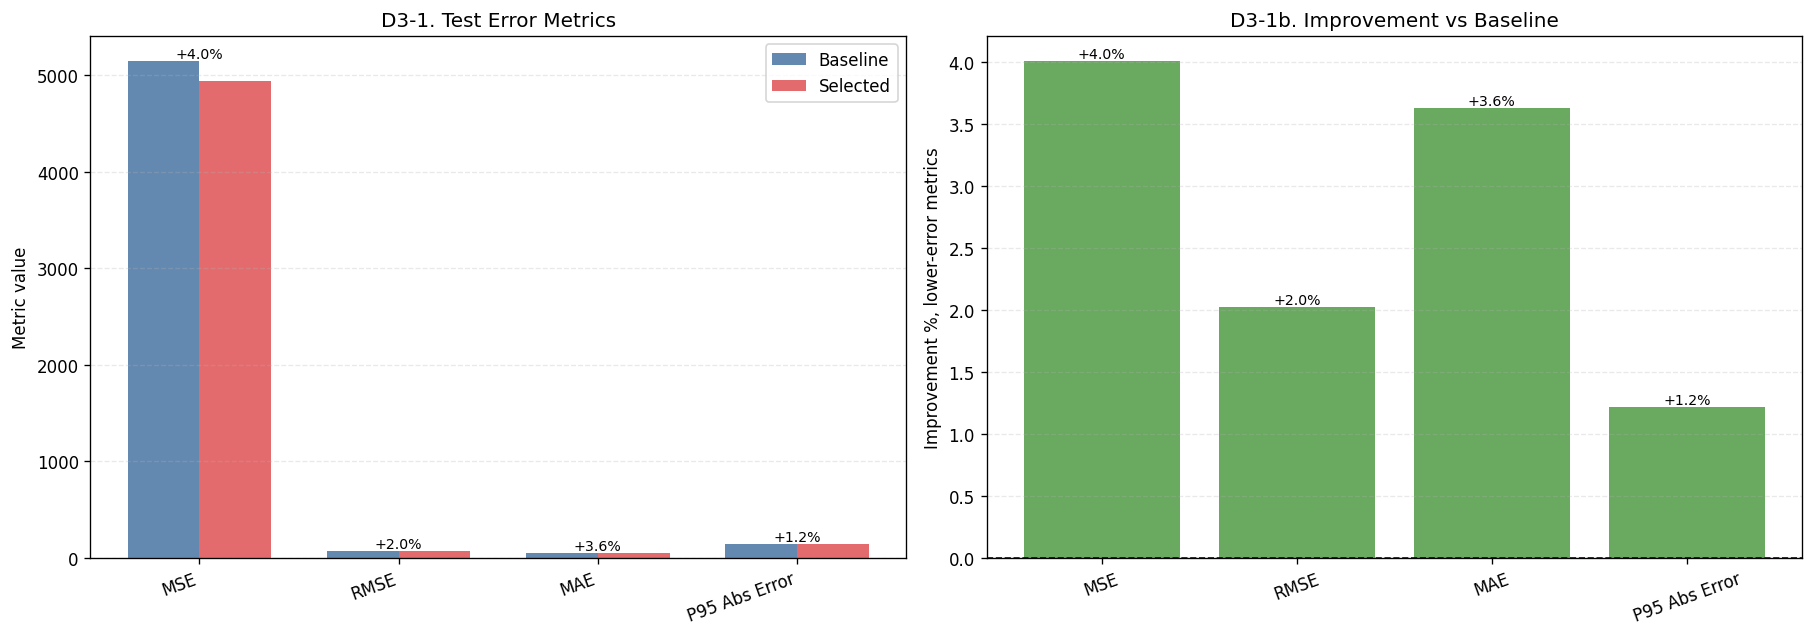

시각화 1 해석:
- 왼쪽 막대그래프는 Baseline과 선택 모델의 test error를 같은 축에서 비교한다.
- 오른쪽 improvement 그래프는 Baseline 대비 오차가 몇 % 줄었는지 직접 보여준다.
- 여기서 양수 개선률이 크면, validation에서 고른 모델이 test에서도 Baseline보다 실질적으로 개선된 것이다.


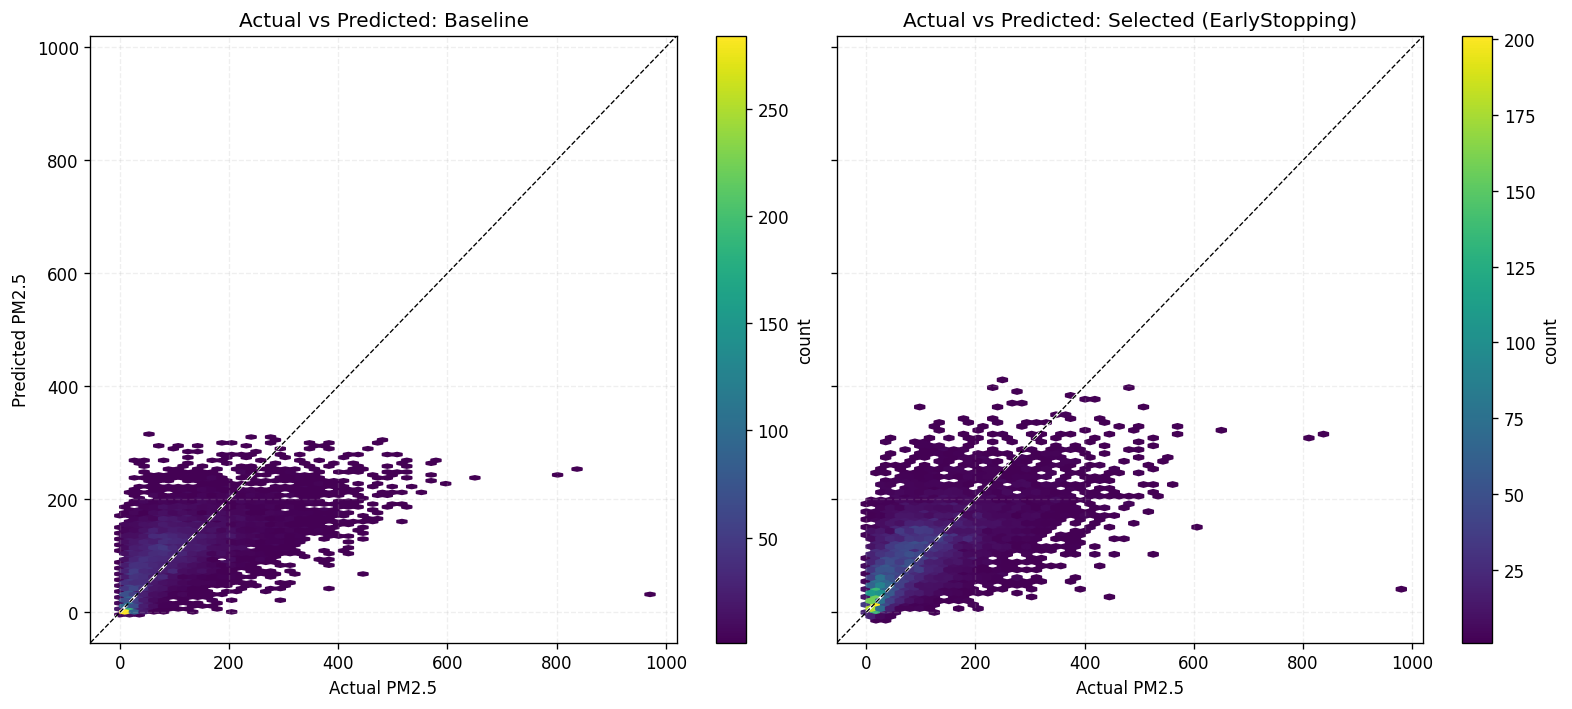

시각화 2 해석:
- 두 그래프는 같은 test set, 같은 x/y 축 범위, 같은 대각선 기준으로 비교한다.
- 점이 대각선 아래에 몰리면 실제 PM2.5보다 낮게 예측한 과소예측이다.
- 선택 모델 그래프에서 고농도 영역의 구름이 Baseline보다 대각선에 가까워졌다면 고농도 episode 대응이 개선된 것이다.
- 반대로 고농도 영역이 여전히 대각선 아래에 있으면, 평균 metric이 좋아져도 위험 구간 예측 한계가 남아 있다.

[D4-0. PM2.5 bin-wise comparison table]


,model,pm25_bin,count,y_true_mean,y_pred_mean,mae,rmse,residual_mean,underprediction_rate,bias
0,Baseline,low_<50%,4352,33.184971,64.871864,40.322502,55.040131,-31.686890,0.299173,overprediction
1,Baseline,mid_50-75%,2205,101.779137,118.329559,37.587124,47.795727,-16.550421,0.360998,overprediction
2,Baseline,high_75-95%,1765,192.043060,144.310379,60.136227,73.685822,47.732685,0.805666,underprediction
3,Baseline,extreme_>=95%,443,365.747192,186.277618,179.545547,197.756027,179.469559,0.997743,underprediction
4,Selected (EarlyStopping),low_<50%,4352,33.184971,61.958050,36.579159,52.009247,-28.773079,0.271140,overprediction
5,Selected (EarlyStopping),mid_50-75%,2205,101.779137,116.262627,39.725945,51.995041,-14.483487,0.397279,overprediction
6,Selected (EarlyStopping),high_75-95%,1765,192.043060,149.152298,61.955353,76.347214,42.890755,0.786969,underprediction
7,Selected (EarlyStopping),extreme_>=95%,443,365.747192,204.195618,162.087677,185.843994,161.551559,0.986456,underprediction


,baseline_mae,selected_mae,mae_delta_selected_minus_baseline,mae_improvement_pct,baseline_mean_residual,selected_mean_residual,baseline_underprediction_rate,selected_underprediction_rate
pm25_bin,,,,,,,,
low_<50%,40.322502,36.579159,-3.743343,9.283510,-31.686890,-28.773079,0.299173,0.271140
mid_50-75%,37.587124,39.725945,2.138821,-5.690301,-16.550421,-14.483487,0.360998,0.397279
high_75-95%,60.136227,61.955353,1.819126,-3.025009,47.732685,42.890755,0.805666,0.786969
extreme_>=95%,179.545547,162.087677,-17.457870,9.723366,179.469559,161.551559,0.997743,0.986456


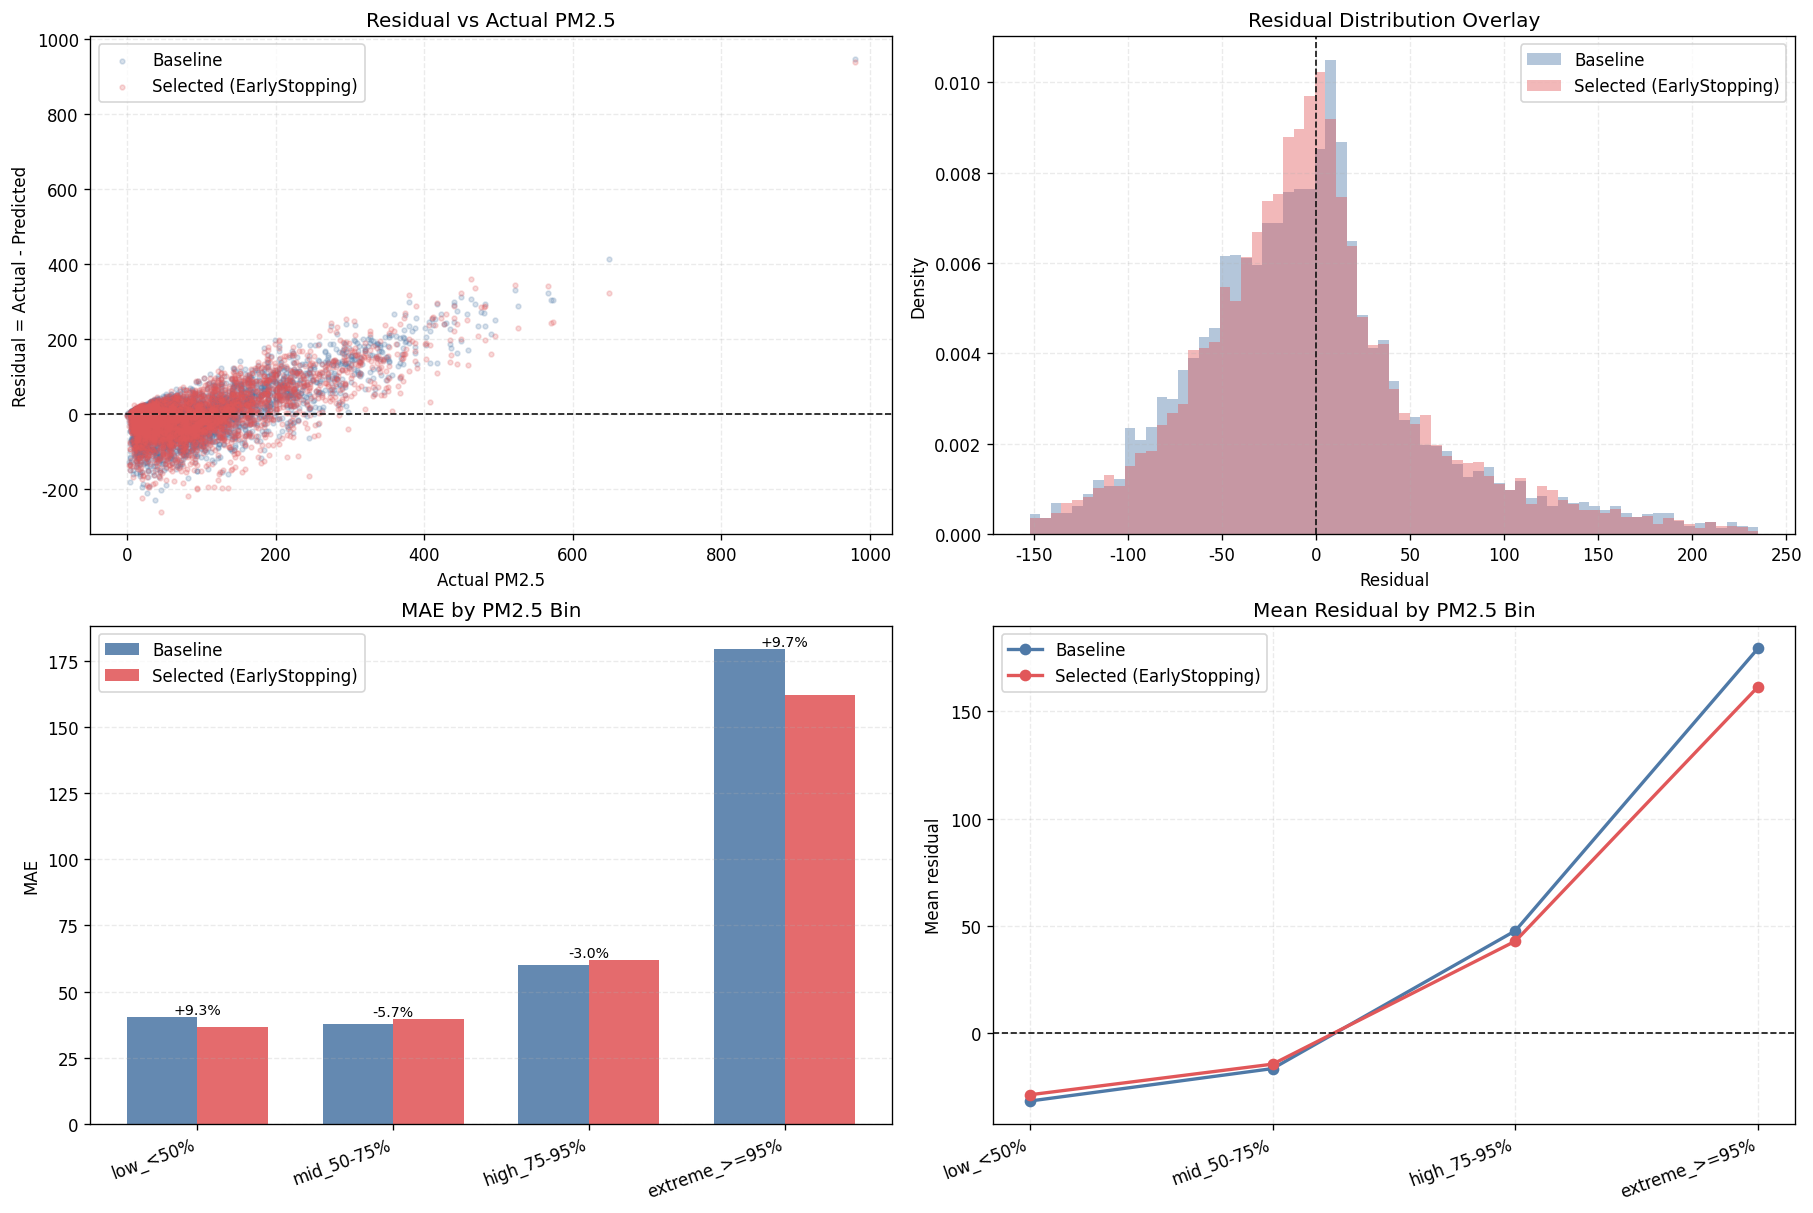

시각화 3 해석:
- Residual overlay는 Baseline과 선택 모델의 오차 구름을 같은 좌표계에 겹쳐서 보여준다.
- Residual distribution overlay에서 선택 모델 분포가 0 주변으로 좁아지면 전체 오차 변동이 줄었다는 뜻이다.
- 농도 구간별 MAE 막대는 평균 성능이 아니라 low/mid/high/extreme 어느 구간에서 개선됐는지 보여준다.
- Mean residual line에서 high/extreme 구간이 양수이면 실제 고농도보다 낮게 예측하는 과소예측이 남아 있는 것이다.

[D 최종 비교 결론]
- 선택 모델: EarlyStopping
- Test MAE 개선율: +3.63%
- Test RMSE 개선율: +2.02%
- Extreme bin MAE 개선율: +9.72%
- Extreme bin selected mean residual: +161.55
- 결론 1: 선택 모델은 Baseline 대비 test 평균 오차를 줄였다.
- 결론 2: extreme PM2.5 구간에서도 Baseline 대비 MAE가 감소했다.
- 결론 3: extreme 구간 residual_mean이 양수이므로, 최종 모델도 고농도 PM2.5를 낮게 예측하는 편향이 남아 있다.


In [30]:
print(' === D3-D4. Baseline vs Selected Model: Test Residual / Bin Error Comparison ===')
print('핵심 질문: 최종 선택 모델이 Baseline 대비 test set에서 실제로 무엇을 얼마나 개선했는가?')
print('D의 결론은 최종 모델 단독 성능이 아니라, Baseline에서 보였던 고농도 과소예측과 구간별 오차가 줄었는지로 판단한다.')

import warnings
warnings.filterwarnings('ignore', message=r'Glyph .* missing from font.*', category=UserWarning)
warnings.filterwarnings('ignore', message=r'.*Glyph .* missing from current font.*', category=UserWarning)

# Plot text is ASCII-only to prevent matplotlib Korean glyph warnings.
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

required_names = ['baseline_model', 'final_model', 'final_model_name', 'X_test', 'y_test']
missing_names = [name for name in required_names if name not in globals()]
if missing_names:
    raise NameError(f'D3-D4 비교 분석 전에 필요한 객체가 없습니다: {missing_names}')

y_test_array = np.asarray(y_test).reshape(-1)
baseline_test_pred = baseline_model.predict(X_test, verbose=0).reshape(-1)
selected_test_pred = final_model.predict(X_test, verbose=0).reshape(-1)

# Keep D2 variable name compatible with the previous notebook flow.
y_test_pred = selected_test_pred

baseline_label = 'Baseline'
selected_label = f'Selected ({final_model_name})'
comparison_order = [baseline_label, selected_label]
model_color = {
    baseline_label: '#4E79A7',
    selected_label: '#E15759'
}

def build_eval_frame(model_label, y_pred):
    residual = y_test_array - y_pred
    return pd.DataFrame({
        'model': model_label,
        'y_true': y_test_array,
        'y_pred': y_pred,
        'residual': residual,
        'abs_error': np.abs(residual),
        'squared_error': residual ** 2,
        'underprediction': residual > 0,
        'overprediction': residual < 0
    })

test_eval_baseline_df = build_eval_frame(baseline_label, baseline_test_pred)
test_eval_selected_df = build_eval_frame(selected_label, selected_test_pred)
test_eval_compare_df = pd.concat(
    [test_eval_baseline_df, test_eval_selected_df],
    ignore_index=True
)
test_eval_compare_df['model'] = pd.Categorical(
    test_eval_compare_df['model'],
    categories=comparison_order,
    ordered=True
)

def regression_metric_row(model_label, y_pred):
    residual = y_test_array - y_pred
    mse = mean_squared_error(y_test_array, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_array, y_pred)
    r2 = r2_score(y_test_array, y_pred)
    return {
        'model': model_label,
        'mse': mse,
        'rmse': rmse,
        'mae': mae,
        'r2': r2,
        'mean_residual': residual.mean(),
        'median_abs_error': np.median(np.abs(residual)),
        'p95_abs_error': np.quantile(np.abs(residual), 0.95),
        'underprediction_rate': np.mean(residual > 0),
        'overprediction_rate': np.mean(residual < 0)
    }

test_metric_compare = pd.DataFrame([
    regression_metric_row(baseline_label, baseline_test_pred),
    regression_metric_row(selected_label, selected_test_pred)
])

test_metric_compare['model'] = pd.Categorical(
    test_metric_compare['model'],
    categories=comparison_order,
    ordered=True
)
test_metric_compare = test_metric_compare.sort_values('model').reset_index(drop=True)

baseline_metrics = test_metric_compare.set_index('model').loc[baseline_label]
selected_metrics = test_metric_compare.set_index('model').loc[selected_label]

test_metric_delta = pd.DataFrame([
    {
        'metric': 'MSE',
        'baseline': baseline_metrics['mse'],
        'selected': selected_metrics['mse'],
        'delta_selected_minus_baseline': selected_metrics['mse'] - baseline_metrics['mse'],
        'improvement_pct_lower_is_better': (baseline_metrics['mse'] - selected_metrics['mse']) / baseline_metrics['mse'] * 100
    },
    {
        'metric': 'RMSE',
        'baseline': baseline_metrics['rmse'],
        'selected': selected_metrics['rmse'],
        'delta_selected_minus_baseline': selected_metrics['rmse'] - baseline_metrics['rmse'],
        'improvement_pct_lower_is_better': (baseline_metrics['rmse'] - selected_metrics['rmse']) / baseline_metrics['rmse'] * 100
    },
    {
        'metric': 'MAE',
        'baseline': baseline_metrics['mae'],
        'selected': selected_metrics['mae'],
        'delta_selected_minus_baseline': selected_metrics['mae'] - baseline_metrics['mae'],
        'improvement_pct_lower_is_better': (baseline_metrics['mae'] - selected_metrics['mae']) / baseline_metrics['mae'] * 100
    },
    {
        'metric': 'P95 Abs Error',
        'baseline': baseline_metrics['p95_abs_error'],
        'selected': selected_metrics['p95_abs_error'],
        'delta_selected_minus_baseline': selected_metrics['p95_abs_error'] - baseline_metrics['p95_abs_error'],
        'improvement_pct_lower_is_better': (baseline_metrics['p95_abs_error'] - selected_metrics['p95_abs_error']) / baseline_metrics['p95_abs_error'] * 100
    },
    {
        'metric': 'R2',
        'baseline': baseline_metrics['r2'],
        'selected': selected_metrics['r2'],
        'delta_selected_minus_baseline': selected_metrics['r2'] - baseline_metrics['r2'],
        'improvement_pct_lower_is_better': np.nan
    }
])

print('\n[D3-0. Test metric comparison table]')
display(test_metric_compare)
display(test_metric_delta)

print('해석:')
print('- MSE/RMSE/MAE/P95 Abs Error는 낮을수록 좋다. improvement_pct가 양수이면 Baseline 대비 개선이다.')
print('- R2는 높을수록 좋으므로 delta_selected_minus_baseline이 양수이면 설명력이 증가한 것이다.')
print('- mean_residual > 0이면 실제값이 예측값보다 큰 경우가 평균적으로 많아 과소예측 편향이 남아 있다는 뜻이다.')

# ---------------------------------------------------------------------
# Figure 1. Metric delta dashboard
# ---------------------------------------------------------------------
metric_plot = test_metric_delta[test_metric_delta['metric'].isin(['MSE', 'RMSE', 'MAE', 'P95 Abs Error'])].copy()
metric_plot['improvement_pct_lower_is_better'] = metric_plot['improvement_pct_lower_is_better'].astype(float)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.2), constrained_layout=True)

x = np.arange(len(metric_plot))
width = 0.36
axes[0].bar(x - width / 2, metric_plot['baseline'], width=width, label='Baseline', color=model_color[baseline_label], alpha=0.88)
axes[0].bar(x + width / 2, metric_plot['selected'], width=width, label='Selected', color=model_color[selected_label], alpha=0.88)
axes[0].set_xticks(x)
axes[0].set_xticklabels(metric_plot['metric'], rotation=20, ha='right')
axes[0].set_title('D3-1. Test Error Metrics')
axes[0].set_ylabel('Metric value')
axes[0].grid(axis='y', linestyle='--', alpha=0.28)
axes[0].legend()

for i, row in metric_plot.reset_index(drop=True).iterrows():
    ymax = max(row['baseline'], row['selected'])
    axes[0].text(i, ymax, f"{row['improvement_pct_lower_is_better']:+.1f}%", ha='center', va='bottom', fontsize=8.5)

improve_colors = ['#59A14F' if v >= 0 else '#E15759' for v in metric_plot['improvement_pct_lower_is_better']]
axes[1].bar(metric_plot['metric'], metric_plot['improvement_pct_lower_is_better'], color=improve_colors, alpha=0.9)
axes[1].axhline(0, color='#111111', linestyle='--', linewidth=1)
axes[1].set_title('D3-1b. Improvement vs Baseline')
axes[1].set_ylabel('Improvement %, lower-error metrics')
axes[1].tick_params(axis='x', rotation=20)
axes[1].grid(axis='y', linestyle='--', alpha=0.28)
for i, v in enumerate(metric_plot['improvement_pct_lower_is_better']):
    va = 'bottom' if v >= 0 else 'top'
    axes[1].text(i, v, f'{v:+.1f}%', ha='center', va=va, fontsize=8.5)

plt.show()

print('시각화 1 해석:')
print('- 왼쪽 막대그래프는 Baseline과 선택 모델의 test error를 같은 축에서 비교한다.')
print('- 오른쪽 improvement 그래프는 Baseline 대비 오차가 몇 % 줄었는지 직접 보여준다.')
print('- 여기서 양수 개선률이 크면, validation에서 고른 모델이 test에서도 Baseline보다 실질적으로 개선된 것이다.')

# ---------------------------------------------------------------------
# Figure 2. Actual vs predicted, same axis scale
# ---------------------------------------------------------------------
axis_min = float(np.nanmin([y_test_array.min(), baseline_test_pred.min(), selected_test_pred.min()]))
axis_max = float(np.nanmax([y_test_array.max(), baseline_test_pred.max(), selected_test_pred.max()]))
axis_min = min(0.0, axis_min)
axis_pad = max((axis_max - axis_min) * 0.04, 1.0)
axis_min -= axis_pad
axis_max += axis_pad

fig, axes = plt.subplots(1, 2, figsize=(13, 5.8), sharex=True, sharey=True, constrained_layout=True)
for ax, model_label, eval_df in [
    (axes[0], baseline_label, test_eval_baseline_df),
    (axes[1], selected_label, test_eval_selected_df)
]:
    hb = ax.hexbin(
        eval_df['y_true'],
        eval_df['y_pred'],
        gridsize=55,
        mincnt=1,
        cmap='viridis'
    )
    ax.plot([axis_min, axis_max], [axis_min, axis_max], linestyle='--', color='white', linewidth=1.6)
    ax.plot([axis_min, axis_max], [axis_min, axis_max], linestyle='--', color='black', linewidth=0.8)
    ax.set_title(f'Actual vs Predicted: {model_label}')
    ax.set_xlabel('Actual PM2.5')
    ax.set_xlim(axis_min, axis_max)
    ax.set_ylim(axis_min, axis_max)
    ax.grid(True, linestyle='--', alpha=0.2)
    cbar = fig.colorbar(hb, ax=ax)
    cbar.set_label('count')
axes[0].set_ylabel('Predicted PM2.5')
plt.show()

print('시각화 2 해석:')
print('- 두 그래프는 같은 test set, 같은 x/y 축 범위, 같은 대각선 기준으로 비교한다.')
print('- 점이 대각선 아래에 몰리면 실제 PM2.5보다 낮게 예측한 과소예측이다.')
print('- 선택 모델 그래프에서 고농도 영역의 구름이 Baseline보다 대각선에 가까워졌다면 고농도 episode 대응이 개선된 것이다.')
print('- 반대로 고농도 영역이 여전히 대각선 아래에 있으면, 평균 metric이 좋아져도 위험 구간 예측 한계가 남아 있다.')

# ---------------------------------------------------------------------
# Figure 3. Residual overlay and PM2.5-bin comparison
# ---------------------------------------------------------------------
rng_seed = int(SEED) if 'SEED' in globals() else 42
rng = np.random.default_rng(rng_seed)
sample_size = min(3500, len(y_test_array))
sample_idx = rng.choice(len(y_test_array), size=sample_size, replace=False)

q50 = np.quantile(y_test_array, 0.50)
q75 = np.quantile(y_test_array, 0.75)
q95 = np.quantile(y_test_array, 0.95)

def pm25_bin_test(x):
    if x < q50:
        return 'low_<50%'
    elif x < q75:
        return 'mid_50-75%'
    elif x < q95:
        return 'high_75-95%'
    else:
        return 'extreme_>=95%'

bin_order = ['low_<50%', 'mid_50-75%', 'high_75-95%', 'extreme_>=95%']
test_eval_compare_df['pm25_bin'] = test_eval_compare_df['y_true'].apply(pm25_bin_test)
test_eval_compare_df['pm25_bin'] = pd.Categorical(
    test_eval_compare_df['pm25_bin'],
    categories=bin_order,
    ordered=True
)

test_bin_error = test_eval_compare_df.groupby(['model', 'pm25_bin'], observed=False).agg(
    count=('y_true', 'count'),
    y_true_mean=('y_true', 'mean'),
    y_pred_mean=('y_pred', 'mean'),
    mae=('abs_error', 'mean'),
    rmse=('squared_error', lambda s: np.sqrt(np.mean(s))),
    residual_mean=('residual', 'mean'),
    underprediction_rate=('underprediction', 'mean')
).reset_index()

test_bin_error['bias'] = np.where(
    test_bin_error['residual_mean'] > 0,
    'underprediction',
    'overprediction'
)

test_bin_mae_wide = test_bin_error.pivot(index='pm25_bin', columns='model', values='mae').loc[bin_order]
test_bin_residual_wide = test_bin_error.pivot(index='pm25_bin', columns='model', values='residual_mean').loc[bin_order]
test_bin_under_rate_wide = test_bin_error.pivot(index='pm25_bin', columns='model', values='underprediction_rate').loc[bin_order]

test_bin_compare = pd.DataFrame({
    'baseline_mae': test_bin_mae_wide[baseline_label],
    'selected_mae': test_bin_mae_wide[selected_label],
    'mae_delta_selected_minus_baseline': test_bin_mae_wide[selected_label] - test_bin_mae_wide[baseline_label],
    'mae_improvement_pct': (test_bin_mae_wide[baseline_label] - test_bin_mae_wide[selected_label]) / test_bin_mae_wide[baseline_label] * 100,
    'baseline_mean_residual': test_bin_residual_wide[baseline_label],
    'selected_mean_residual': test_bin_residual_wide[selected_label],
    'baseline_underprediction_rate': test_bin_under_rate_wide[baseline_label],
    'selected_underprediction_rate': test_bin_under_rate_wide[selected_label]
})

print('\n[D4-0. PM2.5 bin-wise comparison table]')
display(test_bin_error)
display(test_bin_compare)

fig, axes = plt.subplots(2, 2, figsize=(15, 10), constrained_layout=True)

# 3A. Residual vs actual overlay sampled
for model_label, eval_df in [(baseline_label, test_eval_baseline_df), (selected_label, test_eval_selected_df)]:
    axes[0, 0].scatter(
        eval_df['y_true'].to_numpy()[sample_idx],
        eval_df['residual'].to_numpy()[sample_idx],
        s=8,
        alpha=0.22,
        color=model_color[model_label],
        label=model_label
    )
axes[0, 0].axhline(0, color='#111111', linestyle='--', linewidth=1)
axes[0, 0].set_title('Residual vs Actual PM2.5')
axes[0, 0].set_xlabel('Actual PM2.5')
axes[0, 0].set_ylabel('Residual = Actual - Predicted')
axes[0, 0].grid(True, linestyle='--', alpha=0.25)
axes[0, 0].legend()

# 3B. Residual distribution overlay
bins = np.linspace(
    np.quantile(test_eval_compare_df['residual'], 0.01),
    np.quantile(test_eval_compare_df['residual'], 0.99),
    70
)
for model_label, eval_df in [(baseline_label, test_eval_baseline_df), (selected_label, test_eval_selected_df)]:
    axes[0, 1].hist(
        eval_df['residual'],
        bins=bins,
        density=True,
        alpha=0.42,
        color=model_color[model_label],
        label=model_label
    )
axes[0, 1].axvline(0, color='#111111', linestyle='--', linewidth=1)
axes[0, 1].set_title('Residual Distribution Overlay')
axes[0, 1].set_xlabel('Residual')
axes[0, 1].set_ylabel('Density')
axes[0, 1].grid(True, linestyle='--', alpha=0.25)
axes[0, 1].legend()

# 3C. Bin MAE grouped bar
x = np.arange(len(bin_order))
width = 0.36
axes[1, 0].bar(x - width / 2, test_bin_mae_wide[baseline_label], width=width, color=model_color[baseline_label], alpha=0.88, label=baseline_label)
axes[1, 0].bar(x + width / 2, test_bin_mae_wide[selected_label], width=width, color=model_color[selected_label], alpha=0.88, label=selected_label)
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(bin_order, rotation=20, ha='right')
axes[1, 0].set_title('MAE by PM2.5 Bin')
axes[1, 0].set_ylabel('MAE')
axes[1, 0].grid(axis='y', linestyle='--', alpha=0.25)
axes[1, 0].legend()
for i, b in enumerate(bin_order):
    v = test_bin_compare.loc[b, 'mae_improvement_pct']
    y_top = max(test_bin_mae_wide.loc[b, baseline_label], test_bin_mae_wide.loc[b, selected_label])
    axes[1, 0].text(i, y_top, f'{v:+.1f}%', ha='center', va='bottom', fontsize=8.5)

# 3D. Mean residual by bin line overlay
for model_label in comparison_order:
    axes[1, 1].plot(
        x,
        test_bin_residual_wide[model_label].to_numpy(),
        marker='o',
        linewidth=2,
        color=model_color[model_label],
        label=model_label
    )
axes[1, 1].axhline(0, color='#111111', linestyle='--', linewidth=1)
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(bin_order, rotation=20, ha='right')
axes[1, 1].set_title('Mean Residual by PM2.5 Bin')
axes[1, 1].set_ylabel('Mean residual')
axes[1, 1].grid(True, linestyle='--', alpha=0.25)
axes[1, 1].legend()

plt.show()

extreme_row = test_bin_compare.loc['extreme_>=95%']
overall_mae_improve = float(test_metric_delta.loc[test_metric_delta['metric'] == 'MAE', 'improvement_pct_lower_is_better'].iloc[0])
overall_rmse_improve = float(test_metric_delta.loc[test_metric_delta['metric'] == 'RMSE', 'improvement_pct_lower_is_better'].iloc[0])
extreme_mae_improve = float(extreme_row['mae_improvement_pct'])
extreme_residual_selected = float(extreme_row['selected_mean_residual'])

print('시각화 3 해석:')
print('- Residual overlay는 Baseline과 선택 모델의 오차 구름을 같은 좌표계에 겹쳐서 보여준다.')
print('- Residual distribution overlay에서 선택 모델 분포가 0 주변으로 좁아지면 전체 오차 변동이 줄었다는 뜻이다.')
print('- 농도 구간별 MAE 막대는 평균 성능이 아니라 low/mid/high/extreme 어느 구간에서 개선됐는지 보여준다.')
print('- Mean residual line에서 high/extreme 구간이 양수이면 실제 고농도보다 낮게 예측하는 과소예측이 남아 있는 것이다.')

print('\n[D 최종 비교 결론]')
print(f'- 선택 모델: {final_model_name}')
print(f'- Test MAE 개선율: {overall_mae_improve:+.2f}%')
print(f'- Test RMSE 개선율: {overall_rmse_improve:+.2f}%')
print(f'- Extreme bin MAE 개선율: {extreme_mae_improve:+.2f}%')
print(f'- Extreme bin selected mean residual: {extreme_residual_selected:+.2f}')

if overall_mae_improve > 0 and overall_rmse_improve > 0:
    print('- 결론 1: 선택 모델은 Baseline 대비 test 평균 오차를 줄였다.')
else:
    print('- 결론 1: 선택 모델은 validation 기준으로 선택됐지만 test 평균 오차 개선은 충분하지 않다.')

if extreme_mae_improve > 0:
    print('- 결론 2: extreme PM2.5 구간에서도 Baseline 대비 MAE가 감소했다.')
else:
    print('- 결론 2: extreme PM2.5 구간에서는 Baseline 대비 MAE가 줄지 않아 고농도 episode 예측 한계가 남아 있다.')

if extreme_residual_selected > 0:
    print('- 결론 3: extreme 구간 residual_mean이 양수이므로, 최종 모델도 고농도 PM2.5를 낮게 예측하는 편향이 남아 있다.')
else:
    print('- 결론 3: extreme 구간 평균 residual이 0 이하이므로, 고농도 과소예측 편향은 Baseline보다 완화됐다고 볼 수 있다.')



---

# ✅ 제출 전 체크리스트

- [x] STUDENT_ID에 본인 학번을 정확히 입력했나?
- [x] 모든 셀이 위에서 아래로 *실행 가능*한가?
- [x] 모든 필수 출력값이 화면에 나타나는가?

